In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras import layers
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import sys
import os
import re

import pandas as pd
from sklearn.impute import SimpleImputer

# --- Robust loader for CSV / Excel ---
def load_table(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    ext = os.path.splitext(path)[1].lower()
    if ext == '.csv':
        return pd.read_csv(path)
    if ext in ('.xls', '.xlsx'):
        return pd.read_excel(path, engine='openpyxl')
    raise ValueError(f"Unsupported extension: {ext}")

# Load data (handling potential byte order mark)
demographic_df = load_table('delirium cohort demographics.xlsx')

demographic_df = demographic_df.head(128)

serial_df = load_table('serial_norm_gene_exp_df.csv')

serial_df_2 = load_table('serial_samples_annotation.csv').drop(columns = ["Delirium"])

serial_df = serial_df.rename(columns={serial_df.columns[0]: "gene"})

serial_df.set_index("gene", inplace=True)

serial_df = serial_df.T

serial_df = serial_df.reset_index()

serial_df = serial_df.rename(columns = {serial_df.columns[0] : "X"})

merged_serial = merged_df = pd.merge(
    serial_df,          # left dataframe
    serial_df_2,          # right dataframe (same one in this case)
    on="X")

def transform_value(val):
    match = re.search(r"MVIR1.HS(\d+)", str(val))
    if match:
        code = match.group(1)  # extract the digits after MVIR1HS
        return 1000 + int(code)
    return val

merged_serial["X"] = merged_serial["X"].apply(transform_value)
merged_serial.rename(columns={"X": "Master Record ID"}, inplace=True)

combined_df = pd.merge(demographic_df, merged_serial, on='Master Record ID', how='outer')

combined_df.rename(columns={"Delirium at any time during hospitalization": "Delirium"}, inplace=True)

# combined_df = combined_df.drop(columns=["Sequential Organ Failure Assessment (SOFA) Score"])

combined_df = combined_df.drop(columns = ["Diagnosis", "Late_del", "Methylpred given", "Hydrocort given", "Dex given", "Cause of death"])

In [2]:
combined_df_raw = combined_df.copy()

target = "Delirium"

combined_df = combined_df.dropna(subset=[target]).reset_index(drop=True)
print("Shape after dropping rows with missing target:", combined_df.shape)

# 2️⃣ Identify categorical and numeric columns (exclude target)
cat_cols = combined_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_impute_cols = [c for c in cat_cols if c != target]

num_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
num_impute_cols = [c for c in num_cols if c != target]

print("Categorical columns (will fill mode):", cat_impute_cols)
print("Numeric columns (will impute mean):", num_impute_cols)

# 3️⃣ Fill categorical NaNs with mode (most frequent value)
for c in cat_impute_cols:
    mode_vals = combined_df[c].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if not mode_vals.empty else "Missing"
    combined_df[c] = combined_df[c].fillna(fill_val)

# 4️⃣ Impute numeric NaNs with mean, only if there are rows and columns
if num_impute_cols and len(combined_df) > 0:
    # Filter to only include columns that actually exist in combined_df
    existing_num_cols = [col for col in num_impute_cols if col in combined_df.columns]
    
    if existing_num_cols:
        # Use a safer approach - impute one column at a time
        for col in existing_num_cols:
            combined_df[col] = combined_df[col].fillna(combined_df[col].mean())
        print(f"Imputed {len(existing_num_cols)} numeric columns using fillna")
    else:
        print("No existing numeric columns found for imputation")
else:
    print("Skipping numeric imputation: no numeric columns or no rows.")


# 5️⃣ Optional: double-check no NaNs remain
missing_counts = combined_df.isna().sum()
print("Missing values after imputation:\n", missing_counts[missing_counts > 0])

combined_df = combined_df.drop(columns = ["Conv Plasma Date Started", "Conv Plasma HD ended","Master Record ID"])

Shape after dropping rows with missing target: (321, 13138)
Categorical columns (will fill mode): ['Master Record ID', 'Event Name', 'Sequential Organ Failure Assessment (SOFA) Score', 'Age at Admission', 'Sex at Birth', 'Race', 'Hispanic ethnicity', 'Length of Hospitalization', 'ICU Length of Stay', 'SOFA', 'Remdesivir', 'Convalescent plasma', 'IV steroids', 'Dementia', 'Deceased', 'Was patient on ECMO at any point since the last study visit?', 'Non-invasive ventilation (e.g. BiPAP, CPAP)  ', 'Nasal cannula, face mask, or HFNC oxygen therapy', 'Maximum O2 flow via NC or face mask', 'Invasive ventilation']
Numeric columns (will impute mean): ['WHO Scale', 'Remdesivir Date Started (HD)', 'Remdesiver date ended (HD)', 'Conv Plasma Date Started', 'Conv Plasma HD ended', 'IV steroid HD started', 'IV steroid HD ended', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1', 'NIPAL3', 'LAS1L', 'ENPP4', 'ANKIB1', 'CYP51A1', 'KRIT1', 'RAD52', 'BAD', 'LAP3', 'CD99', 'HS3ST1

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_59063/1057118288.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df[c] = combined_df[c].fillna(fill_val)


Imputed 13117 numeric columns using fillna
Missing values after imputation:
 Conv Plasma Date Started    321
Conv Plasma HD ended        321
dtype: int64


In [3]:
# ...existing code...
# new cell: train/tune multiple models and plot ROC curves

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from scipy.special import expit

# Optional imblearn
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except Exception:
    has_smote = False

# Use combined_df prepared earlier in this notebook
# link: [`combined_df`](Untitled.ipynb)
df = combined_df.copy()

target = "Delirium"
if target not in df.columns:
    raise RuntimeError(f"Target column '{target}' not found in combined_df")

# prepare X,y: drop non-numeric and obvious id cols
y = df[target].values

X_df = df.drop(columns=[target]).select_dtypes(include=[np.number]).copy()
if X_df.shape[1] == 0:
    raise RuntimeError("No numeric features found in combined_df after dropping target")

X_df = X_df.fillna(X_df.mean())
scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# train/test split stratified
if len(np.unique(y)) < 2:
    raise RuntimeError("Target has single class")
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# helper to evaluate and plot
roc_results = {}
def evaluate_and_plot(name, y_proba):
    if np.unique(y_test).size < 2:
        print(f"Skipping {name}: y_test has single class")
        return
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    y_pred = (y_proba > 0.5).astype(int)
    print(f"\n{name} — AUC: {auc:.4f}")
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print(classification_report(y_test, y_pred, zero_division=0))
    plt.figure(figsize=(6.5,5))
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.title(f"ROC — {name}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.show()
    roc_results[name] = (fpr, tpr, auc)

# Utility: robust proba extractor
def get_proba(model, X):
    try:
        return model.predict_proba(X)[:,1]
    except Exception:
        try:
            d = model.decision_function(X)
            return expit(d)
        except Exception:
            p = model.predict(X)
            if p.ndim == 1:
                return p
            return np.asarray(p).ravel()


RF best params: {'n_estimators': 200, 'min_samples_split': 8, 'max_depth': 20, 'class_weight': 'balanced'}

RandomForest — AUC: 0.8980
Precision: 0.8421052631578947
Recall: 0.64
              precision    recall  f1-score   support

         0.0       0.80      0.93      0.86        40
         1.0       0.84      0.64      0.73        25

    accuracy                           0.82        65
   macro avg       0.82      0.78      0.79        65
weighted avg       0.82      0.82      0.81        65



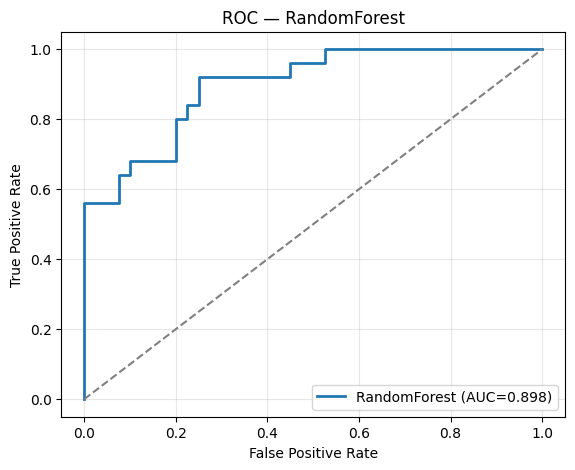

In [4]:

# 1) Random Forest (Randomized search)
rf = RandomForestClassifier(random_state=0)
rf_params = {'n_estimators':[100,200,400,800], 'max_depth':[None,10,20,40], 'min_samples_split':[2,4,8], 'class_weight':[None,'balanced']}
rs_rf = RandomizedSearchCV(rf, rf_params, n_iter=12, scoring='roc_auc', cv=skf, random_state=0, n_jobs=-1)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
y_proba_rf = get_proba(best_rf, X_test)
print("RF best params:", rs_rf.best_params_)
evaluate_and_plot("RandomForest", y_proba_rf)


In [5]:
#most important features
import shap

# Create SHAP explainer for Random Forest
explainer_rf = shap.TreeExplainer(best_rf)

# Get SHAP values for training data (or a subset)
# Use a subset of data if the full dataset is too large
X_train_subset = X_train[:100]  # Use first 100 samples
shap_values_rf = explainer_rf.shap_values(X_train_subset)

# Handle different SHAP output formats across versions (list per class vs array)
if isinstance(shap_values_rf, list):
    # multiclass or two-entry list (neg,class) -> prefer positive class if present
    vals = shap_values_rf[1] if len(shap_values_rf) > 1 else shap_values_rf[0]
else:
    vals = shap_values_rf

# Get mean absolute SHAP values for each feature
mean_shap_values = np.mean(np.abs(vals), axis=0)

# Ensure mean_shap_values is 1D and has the right length
if mean_shap_values.ndim > 1:
    mean_shap_values = mean_shap_values.flatten()

# Verify the length matches the number of features
if len(mean_shap_values) != len(X_df.columns):
    print(f"Warning: SHAP values length ({len(mean_shap_values)}) doesn't match features ({len(X_df.columns)})")
    # Truncate or pad to match
    if len(mean_shap_values) > len(X_df.columns):
        mean_shap_values = mean_shap_values[:len(X_df.columns)]
    else:
        # Pad with zeros if too short
        mean_shap_values = np.pad(mean_shap_values, (0, len(X_df.columns) - len(mean_shap_values)), 'constant')

# Create DataFrame with SHAP importance
shap_importance_df = pd.DataFrame({
    'feature': X_df.columns,
    'shap_importance': mean_shap_values
})

# Sort by SHAP importance
shap_importance_df = shap_importance_df.sort_values('shap_importance', ascending=False)

# Show top features by SHAP
print("Top 20 Features by SHAP Importance:")
print(shap_importance_df.head(20))

Top 20 Features by SHAP Importance:
                           feature  shap_importance
2               ICU Length of Stay         0.012428
3                             SOFA         0.012428
5     Remdesivir Date Started (HD)         0.012103
4                        WHO Scale         0.012103
7            IV steroid HD started         0.011056
6       Remdesiver date ended (HD)         0.011056
1        Length of Hospitalization         0.004976
0                 Age at Admission         0.004976
9                             DPM1         0.004406
8              IV steroid HD ended         0.004406
8456                         LAIR2         0.002875
8457                        ZNF526         0.002875
12                             FGR         0.002632
13                             CFH         0.002632
11                        C1orf112         0.002314
10                           SCYL3         0.002314
9920                          SSR4         0.002053
9921                        

=== ENHANCED SHAP ANALYSIS: TRAINING vs TEST DATA ===

1. Training Data SHAP Analysis (Stable Feature Importance):
✓ Training data SHAP analysis completed
Top 10 Features (Training Data):
                            feature  shap_importance_train
29                             AOC1           3.767859e-18
3                              SOFA           3.434752e-18
4                         WHO Scale           2.978439e-18
1         Length of Hospitalization           2.916504e-18
5      Remdesivir Date Started (HD)           2.748368e-18
3601                           MREG           2.706643e-18
3586                          ESYT2           2.647757e-18
3241                          HEMK1           2.505168e-18
0                  Age at Admission           2.491226e-18
11709                         MAP10           2.485308e-18

2. Test Data SHAP Analysis (Validation):
✓ Test data SHAP analysis completed
Top 10 Features (Test Data):
                         feature  shap_importance_test
2

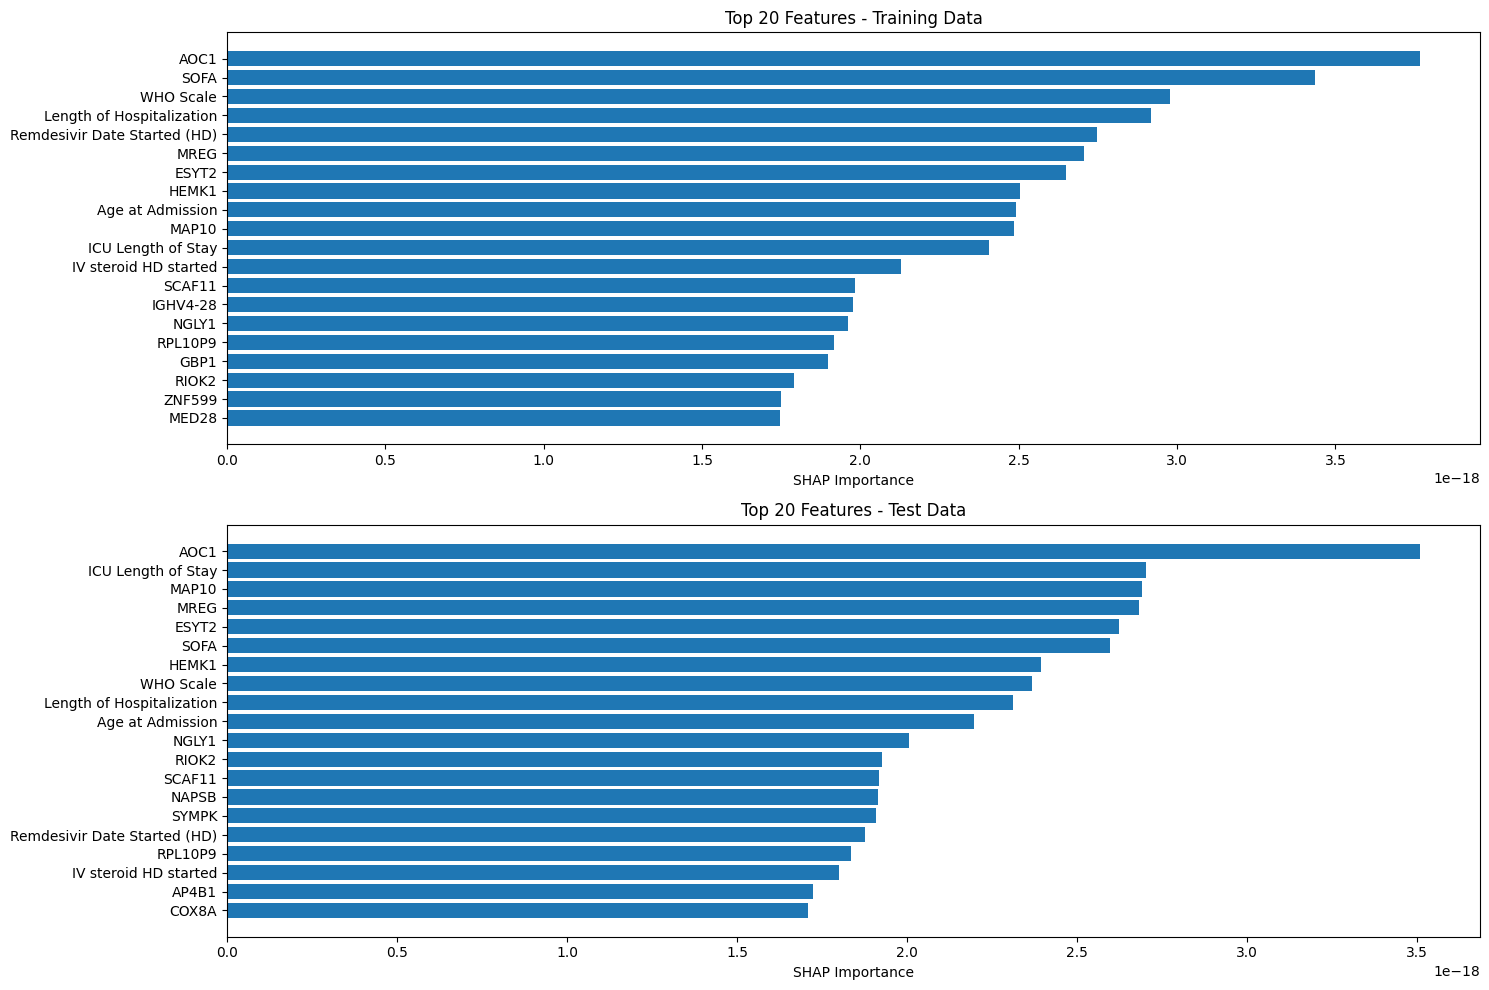

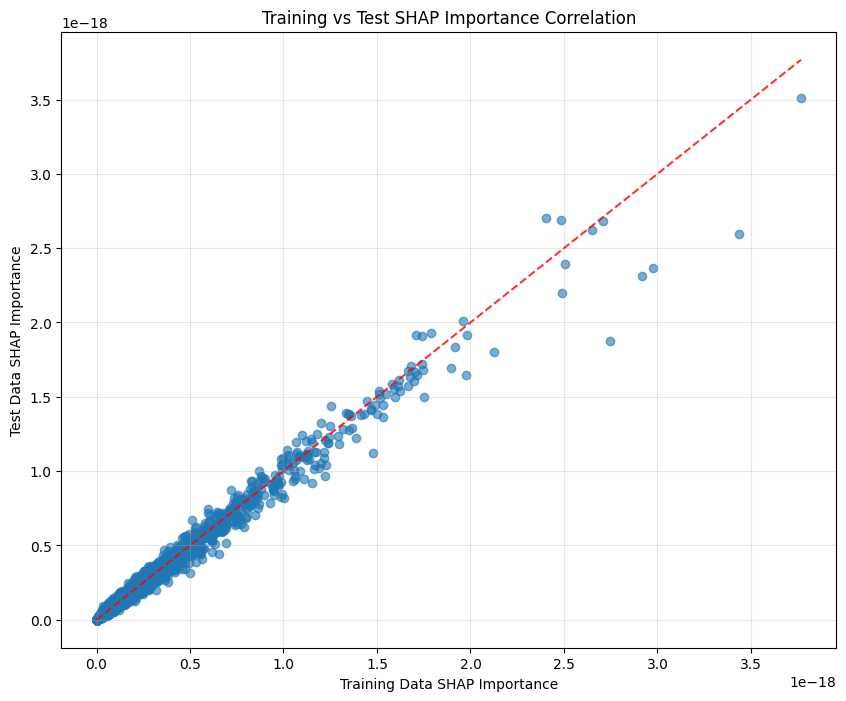

✓ Visualizations completed

5. Summary Statistics:
Training data - Top feature: AOC1 (importance: 0.000000)
Test data - Top feature: AOC1 (importance: 0.000000)
Top 5 features overlap: 1/5 (20.0%)

=== ENHANCED SHAP ANALYSIS COMPLETED ===


In [6]:
# Enhanced SHAP Analysis: Training vs Test Data Comparison
import shap
import matplotlib.pyplot as plt
import numpy as np

print("=== ENHANCED SHAP ANALYSIS: TRAINING vs TEST DATA ===")

# 1. Training Data Analysis (for stable feature importance)
print("\n1. Training Data SHAP Analysis (Stable Feature Importance):")
try:
    explainer_rf_train = shap.TreeExplainer(best_rf)
    
    # Use subset of training data to avoid memory issues
    X_train_subset = X_train[:100]  # First 100 training samples
    shap_values_train = explainer_rf_train.shap_values(X_train_subset)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_train, list):
        vals_train = shap_values_train[1] if len(shap_values_train) > 1 else shap_values_train[0]
    else:
        vals_train = shap_values_train
    
    # Ensure 2D array
    if vals_train.ndim == 3:
        vals_train = np.mean(vals_train, axis=2)
    elif vals_train.ndim == 1:
        vals_train = vals_train.reshape(1, -1)
    
    # Get mean absolute SHAP values for training data
    mean_shap_train = np.mean(np.abs(vals_train), axis=0)
    if mean_shap_train.ndim > 1:
        mean_shap_train = mean_shap_train.flatten()
    
    # Create training data importance DataFrame
    train_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_train': mean_shap_train
    }).sort_values('shap_importance_train', ascending=False)
    
    print("✓ Training data SHAP analysis completed")
    print(f"Top 10 Features (Training Data):")
    print(train_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Training data SHAP analysis failed: {e}")
    train_importance_df = None

# 2. Test Data Analysis (for validation)
print("\n2. Test Data SHAP Analysis (Validation):")
try:
    explainer_rf_test = shap.TreeExplainer(best_rf)
    
    # Use subset of test data
    X_test_subset = X_test[:50]  # First 50 test samples
    shap_values_test = explainer_rf_test.shap_values(X_test_subset)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_test, list):
        vals_test = shap_values_test[1] if len(shap_values_test) > 1 else shap_values_test[0]
    else:
        vals_test = shap_values_test
    
    # Ensure 2D array
    if vals_test.ndim == 3:
        vals_test = np.mean(vals_test, axis=2)
    elif vals_test.ndim == 1:
        vals_test = vals_test.reshape(1, -1)
    
    # Get mean absolute SHAP values for test data
    mean_shap_test = np.mean(np.abs(vals_test), axis=0)
    if mean_shap_test.ndim > 1:
        mean_shap_test = mean_shap_test.flatten()
    
    # Create test data importance DataFrame
    test_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_test': mean_shap_test
    }).sort_values('shap_importance_test', ascending=False)
    
    print("✓ Test data SHAP analysis completed")
    print(f"Top 10 Features (Test Data):")
    print(test_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Test data SHAP analysis failed: {e}")
    test_importance_df = None

# 3. Comparison Analysis
print("\n3. Training vs Test Data Comparison:")
if train_importance_df is not None and test_importance_df is not None:
    try:
        # Merge training and test importance
        comparison_df = pd.merge(
            train_importance_df, 
            test_importance_df, 
            on='feature', 
            how='outer'
        ).fillna(0)
        
        # Calculate correlation between training and test importance
        correlation = comparison_df['shap_importance_train'].corr(comparison_df['shap_importance_test'])
        print(f"Correlation between training and test importance: {correlation:.4f}")
        
        # Show features that are important in both datasets
        top_train = set(train_importance_df.head(20)['feature'])
        top_test = set(test_importance_df.head(20)['feature'])
        common_important = top_train.intersection(top_test)
        
        print(f"\nFeatures important in BOTH training and test data (Top 20 overlap):")
        print(f"Number of common features: {len(common_important)}")
        if len(common_important) > 0:
            common_df = comparison_df[comparison_df['feature'].isin(common_important)].sort_values('shap_importance_train', ascending=False)
            print(common_df.head(10))
        
        # Show features with biggest differences
        comparison_df['importance_diff'] = abs(comparison_df['shap_importance_train'] - comparison_df['shap_importance_test'])
        most_different = comparison_df.nlargest(10, 'importance_diff')
        print(f"\nFeatures with biggest difference between training and test:")
        print(most_different[['feature', 'shap_importance_train', 'shap_importance_test', 'importance_diff']])
        
    except Exception as e:
        print(f"❌ Comparison analysis failed: {e}")

# 4. Visualization
print("\n4. Creating Visualizations:")
try:
    if train_importance_df is not None and test_importance_df is not None:
        # Plot top features comparison
        plt.figure(figsize=(15, 10))
        
        # Subplot 1: Top 20 features from training data
        plt.subplot(2, 1, 1)
        top_train_plot = train_importance_df.head(20)
        plt.barh(range(len(top_train_plot)), top_train_plot['shap_importance_train'])
        plt.yticks(range(len(top_train_plot)), top_train_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Training Data')
        plt.gca().invert_yaxis()
        
        # Subplot 2: Top 20 features from test data
        plt.subplot(2, 1, 2)
        top_test_plot = test_importance_df.head(20)
        plt.barh(range(len(top_test_plot)), top_test_plot['shap_importance_test'])
        plt.yticks(range(len(top_test_plot)), top_test_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Test Data')
        plt.gca().invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of training vs test importance
        plt.figure(figsize=(10, 8))
        plt.scatter(comparison_df['shap_importance_train'], comparison_df['shap_importance_test'], alpha=0.6)
        plt.plot([0, comparison_df['shap_importance_train'].max()], [0, comparison_df['shap_importance_train'].max()], 'r--', alpha=0.8)
        plt.xlabel('Training Data SHAP Importance')
        plt.ylabel('Test Data SHAP Importance')
        plt.title('Training vs Test SHAP Importance Correlation')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print("✓ Visualizations completed")
        
except Exception as e:
    print(f"❌ Visualization failed: {e}")

# 5. Summary Statistics
print("\n5. Summary Statistics:")
if train_importance_df is not None and test_importance_df is not None:
    print(f"Training data - Top feature: {train_importance_df.iloc[0]['feature']} (importance: {train_importance_df.iloc[0]['shap_importance_train']:.6f})")
    print(f"Test data - Top feature: {test_importance_df.iloc[0]['feature']} (importance: {test_importance_df.iloc[0]['shap_importance_test']:.6f})")
    
    # Check stability
    train_top5 = set(train_importance_df.head(5)['feature'])
    test_top5 = set(test_importance_df.head(5)['feature'])
    overlap_5 = len(train_top5.intersection(test_top5))
    print(f"Top 5 features overlap: {overlap_5}/5 ({overlap_5/5*100:.1f}%)")

print("\n=== ENHANCED SHAP ANALYSIS COMPLETED ===")

LogReg best params: {'C': 1, 'penalty': 'l1'}

LogisticRegression — AUC: 0.9740
Precision: 1.0
Recall: 0.8
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        40
         1.0       1.00      0.80      0.89        25

    accuracy                           0.92        65
   macro avg       0.94      0.90      0.92        65
weighted avg       0.93      0.92      0.92        65



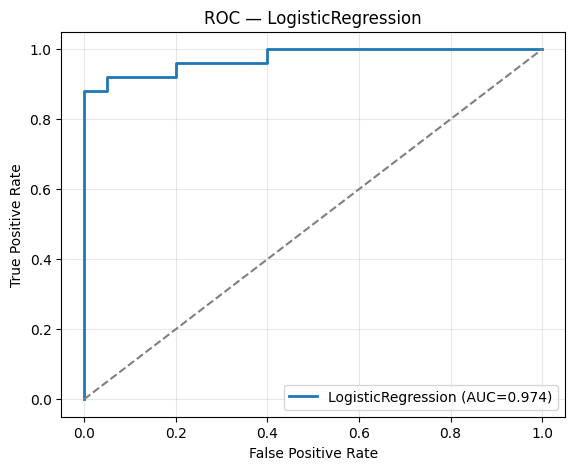

In [8]:

# 2) Logistic Regression (Grid)
lr = LogisticRegression(solver='liblinear', max_iter=2000)
lr_grid = {'C':[0.001,0.01,0.1,1,10], 'penalty':['l2','l1']}
gs_lr = GridSearchCV(lr, lr_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
gs_lr.fit(X_train, y_train)
best_lr = gs_lr.best_estimator_
y_proba_lr = get_proba(best_lr, X_test)
print("LogReg best params:", gs_lr.best_params_)
evaluate_and_plot("LogisticRegression", y_proba_lr)


=== ENHANCED SHAP ANALYSIS FOR LOGISTIC REGRESSION ===

1. Training Data SHAP Analysis (Stable Feature Importance):


  0%|          | 0/100 [00:00<?, ?it/s]

✓ Training data SHAP analysis completed
Top 10 Features (Training Data):
       feature  shap_importance_train
216       MRC2           1.729382e+16
419      TIMP2           1.729382e+16
2281    CLPTM1           1.263260e+15
2003     STAG2           1.263260e+15
6911    HS2ST1           1.441152e+14
2598   SEC23IP           1.373598e+14
866       SMG6           5.420071e+13
1512  SLC22A17           5.420071e+13
1476     KIF4A           3.393240e+13
789    DNTTIP2           3.393240e+13

2. Test Data SHAP Analysis (Validation):


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Test data SHAP analysis completed
Top 10 Features (Test Data):
                         feature  shap_importance_test
8940                        FPR2          8.209869e+14
2881                       PSMD9          8.209869e+14
496                         MAP4          1.147562e+14
3462                        MIIP          1.147562e+14
1      Length of Hospitalization          9.132312e+13
712                         IPO5          9.132312e+13
4806                        SCLY          8.414495e+13
11533                      KLRC2          8.414495e+13
12012                    RPL27P4          6.677634e+13
2460                       BRAT1          6.677634e+13

3. Training vs Test Data Comparison:
Correlation between training and test importance: -0.0002

Features important in BOTH training and test data (Top 20 overlap):
Number of common features: 0

Features with biggest difference between training and test:
       feature  shap_importance_train  shap_importance_test  importance_dif

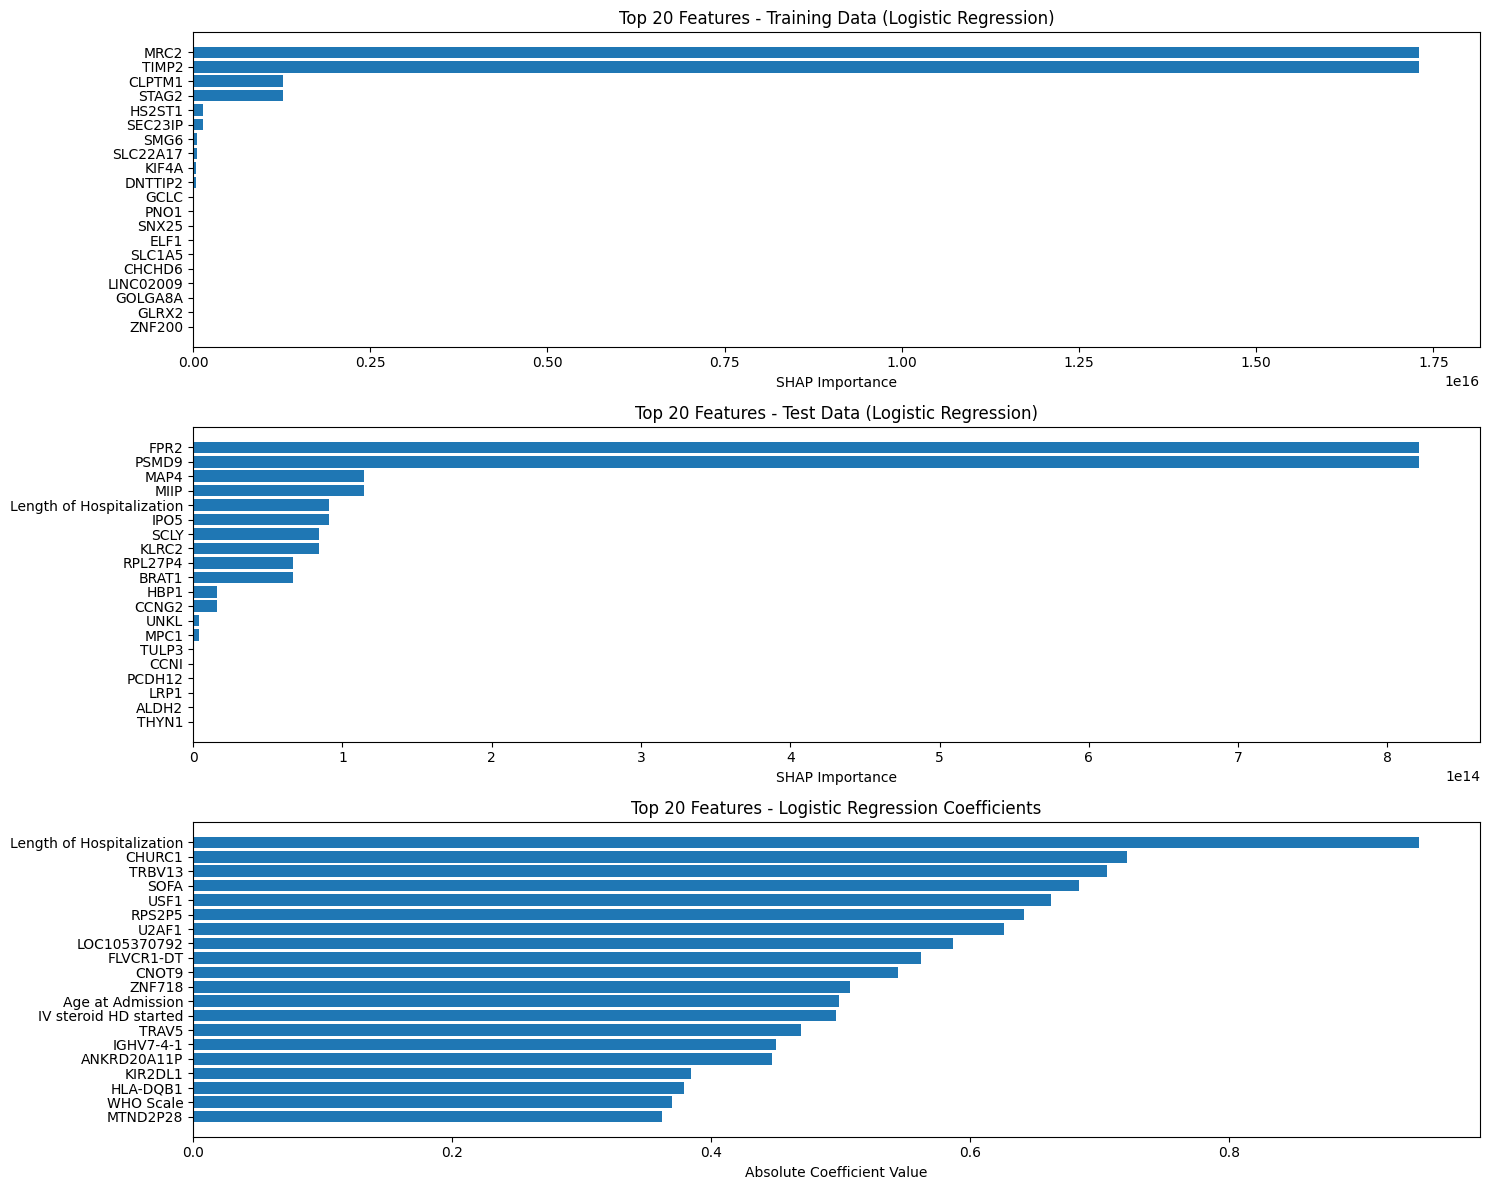

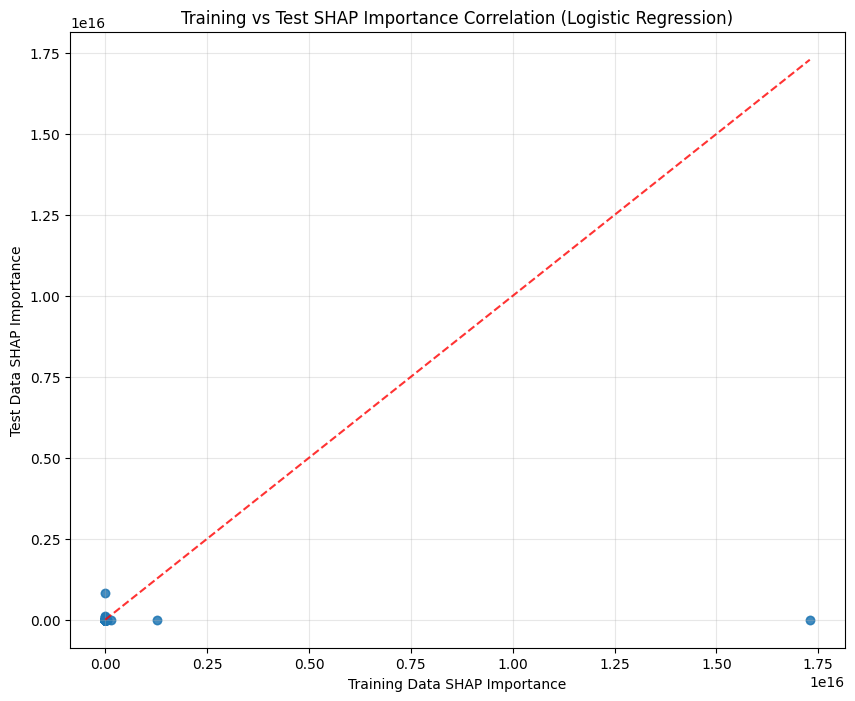

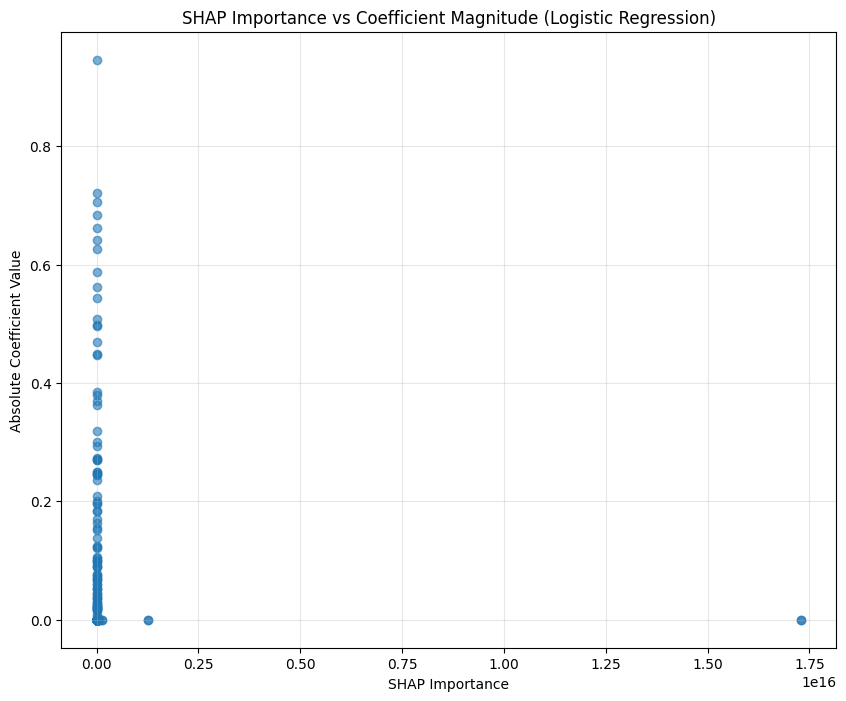

✓ Visualizations completed

6. Summary Statistics:
Training data - Top feature: MRC2 (importance: 17293822569102704.000000)
Test data - Top feature: FPR2 (importance: 820986877233272.125000)
Top 5 features overlap: 0/5 (0.0%)
Logistic Regression - Top feature: Length of Hospitalization (coefficient: 0.946071)
Number of positive coefficients: 55
Number of negative coefficients: 36

=== ENHANCED SHAP ANALYSIS FOR LOGISTIC REGRESSION COMPLETED ===


In [9]:
# Enhanced SHAP Analysis for Logistic Regression Model
import shap
import matplotlib.pyplot as plt
import numpy as np

print("=== ENHANCED SHAP ANALYSIS FOR LOGISTIC REGRESSION ===")

# 1. Training Data Analysis (for stable feature importance)
print("\n1. Training Data SHAP Analysis (Stable Feature Importance):")
try:
    # Create summary of training data for KernelExplainer
    X_train_summary = shap.kmeans(X_train, 50)  # Using 50 samples for summary
    
    # Create explainer for Logistic Regression
    explainer_lr_train = shap.KernelExplainer(best_lr.predict_proba, X_train_summary)
    
    # Use subset of training data to avoid memory issues
    X_train_subset = X_train[:100]  # First 100 training samples
    shap_values_train = explainer_lr_train.shap_values(X_train_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_train, list):
        vals_train = shap_values_train[1] if len(shap_values_train) > 1 else shap_values_train[0]
    else:
        vals_train = shap_values_train
    
    # Ensure 2D array
    if vals_train.ndim == 3:
        vals_train = np.mean(vals_train, axis=2)
    elif vals_train.ndim == 1:
        vals_train = vals_train.reshape(1, -1)
    
    # Get mean absolute SHAP values for training data
    mean_shap_train = np.mean(np.abs(vals_train), axis=0)
    if mean_shap_train.ndim > 1:
        mean_shap_train = mean_shap_train.flatten()
    
    # Create training data importance DataFrame
    train_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_train': mean_shap_train
    }).sort_values('shap_importance_train', ascending=False)
    
    print("✓ Training data SHAP analysis completed")
    print(f"Top 10 Features (Training Data):")
    print(train_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Training data SHAP analysis failed: {e}")
    train_importance_df = None

# 2. Test Data Analysis (for validation)
print("\n2. Test Data SHAP Analysis (Validation):")
try:
    # Use same explainer but with test data
    X_test_subset = X_test[:50]  # First 50 test samples
    shap_values_test = explainer_lr_train.shap_values(X_test_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_test, list):
        vals_test = shap_values_test[1] if len(shap_values_test) > 1 else shap_values_test[0]
    else:
        vals_test = shap_values_test
    
    # Ensure 2D array
    if vals_test.ndim == 3:
        vals_test = np.mean(vals_test, axis=2)
    elif vals_test.ndim == 1:
        vals_test = vals_test.reshape(1, -1)
    
    # Get mean absolute SHAP values for test data
    mean_shap_test = np.mean(np.abs(vals_test), axis=0)
    if mean_shap_test.ndim > 1:
        mean_shap_test = mean_shap_test.flatten()
    
    # Create test data importance DataFrame
    test_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_test': mean_shap_test
    }).sort_values('shap_importance_test', ascending=False)
    
    print("✓ Test data SHAP analysis completed")
    print(f"Top 10 Features (Test Data):")
    print(test_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Test data SHAP analysis failed: {e}")
    test_importance_df = None

# 3. Comparison Analysis
print("\n3. Training vs Test Data Comparison:")
if train_importance_df is not None and test_importance_df is not None:
    try:
        # Merge training and test importance
        comparison_df = pd.merge(
            train_importance_df, 
            test_importance_df, 
            on='feature', 
            how='outer'
        ).fillna(0)
        
        # Calculate correlation between training and test importance
        correlation = comparison_df['shap_importance_train'].corr(comparison_df['shap_importance_test'])
        print(f"Correlation between training and test importance: {correlation:.4f}")
        
        # Show features that are important in both datasets
        top_train = set(train_importance_df.head(20)['feature'])
        top_test = set(test_importance_df.head(20)['feature'])
        common_important = top_train.intersection(top_test)
        
        print(f"\nFeatures important in BOTH training and test data (Top 20 overlap):")
        print(f"Number of common features: {len(common_important)}")
        if len(common_important) > 0:
            common_df = comparison_df[comparison_df['feature'].isin(common_important)].sort_values('shap_importance_train', ascending=False)
            print(common_df.head(10))
        
        # Show features with biggest differences
        comparison_df['importance_diff'] = abs(comparison_df['shap_importance_train'] - comparison_df['shap_importance_test'])
        most_different = comparison_df.nlargest(10, 'importance_diff')
        print(f"\nFeatures with biggest difference between training and test:")
        print(most_different[['feature', 'shap_importance_train', 'shap_importance_test', 'importance_diff']])
        
    except Exception as e:
        print(f"❌ Comparison analysis failed: {e}")

# 4. Logistic Regression Specific Analysis
print("\n4. Logistic Regression Specific Analysis:")
try:
    if train_importance_df is not None:
        # Compare SHAP importance with model coefficients
        lr_coefficients = best_lr.coef_[0]  # Get coefficients for positive class
        
        # Create coefficient DataFrame
        coef_df = pd.DataFrame({
            'feature': X_df.columns,
            'lr_coefficient': lr_coefficients,
            'abs_coefficient': np.abs(lr_coefficients)
        }).sort_values('abs_coefficient', ascending=False)
        
        print("Top 10 Features by Logistic Regression Coefficients:")
        print(coef_df.head(10))
        
        # Compare SHAP importance with coefficient importance
        if train_importance_df is not None:
            comparison_coef = pd.merge(
                train_importance_df, 
                coef_df[['feature', 'abs_coefficient']], 
                on='feature', 
                how='outer'
            ).fillna(0)
            
            # Calculate correlation between SHAP and coefficient importance
            shap_coef_corr = comparison_coef['shap_importance_train'].corr(comparison_coef['abs_coefficient'])
            print(f"\nCorrelation between SHAP importance and coefficient magnitude: {shap_coef_corr:.4f}")
            
            # Show features with biggest differences between SHAP and coefficient importance
            comparison_coef['shap_coef_diff'] = abs(comparison_coef['shap_importance_train'] - comparison_coef['abs_coefficient'])
            most_different_coef = comparison_coef.nlargest(10, 'shap_coef_diff')
            print(f"\nFeatures with biggest difference between SHAP and coefficient importance:")
            print(most_different_coef[['feature', 'shap_importance_train', 'abs_coefficient', 'shap_coef_diff']])
            
except Exception as e:
    print(f"❌ Logistic Regression specific analysis failed: {e}")

# 5. Visualization
print("\n5. Creating Visualizations:")
try:
    if train_importance_df is not None and test_importance_df is not None:
        # Plot top features comparison
        plt.figure(figsize=(15, 12))
        
        # Subplot 1: Top 20 features from training data
        plt.subplot(3, 1, 1)
        top_train_plot = train_importance_df.head(20)
        plt.barh(range(len(top_train_plot)), top_train_plot['shap_importance_train'])
        plt.yticks(range(len(top_train_plot)), top_train_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Training Data (Logistic Regression)')
        plt.gca().invert_yaxis()
        
        # Subplot 2: Top 20 features from test data
        plt.subplot(3, 1, 2)
        top_test_plot = test_importance_df.head(20)
        plt.barh(range(len(top_test_plot)), top_test_plot['shap_importance_test'])
        plt.yticks(range(len(top_test_plot)), top_test_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Test Data (Logistic Regression)')
        plt.gca().invert_yaxis()
        
        # Subplot 3: Top 20 features by coefficients
        if 'coef_df' in locals():
            plt.subplot(3, 1, 3)
            top_coef_plot = coef_df.head(20)
            plt.barh(range(len(top_coef_plot)), top_coef_plot['abs_coefficient'])
            plt.yticks(range(len(top_coef_plot)), top_coef_plot['feature'])
            plt.xlabel('Absolute Coefficient Value')
            plt.title('Top 20 Features - Logistic Regression Coefficients')
            plt.gca().invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of training vs test importance
        plt.figure(figsize=(10, 8))
        plt.scatter(comparison_df['shap_importance_train'], comparison_df['shap_importance_test'], alpha=0.6)
        plt.plot([0, comparison_df['shap_importance_train'].max()], [0, comparison_df['shap_importance_train'].max()], 'r--', alpha=0.8)
        plt.xlabel('Training Data SHAP Importance')
        plt.ylabel('Test Data SHAP Importance')
        plt.title('Training vs Test SHAP Importance Correlation (Logistic Regression)')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Scatter plot of SHAP vs coefficient importance
        if 'comparison_coef' in locals():
            plt.figure(figsize=(10, 8))
            plt.scatter(comparison_coef['shap_importance_train'], comparison_coef['abs_coefficient'], alpha=0.6)
            plt.xlabel('SHAP Importance')
            plt.ylabel('Absolute Coefficient Value')
            plt.title('SHAP Importance vs Coefficient Magnitude (Logistic Regression)')
            plt.grid(True, alpha=0.3)
            plt.show()
        
        print("✓ Visualizations completed")
        
except Exception as e:
    print(f"❌ Visualization failed: {e}")

# 6. Summary Statistics
print("\n6. Summary Statistics:")
if train_importance_df is not None and test_importance_df is not None:
    print(f"Training data - Top feature: {train_importance_df.iloc[0]['feature']} (importance: {train_importance_df.iloc[0]['shap_importance_train']:.6f})")
    print(f"Test data - Top feature: {test_importance_df.iloc[0]['feature']} (importance: {test_importance_df.iloc[0]['shap_importance_test']:.6f})")
    
    # Check stability
    train_top5 = set(train_importance_df.head(5)['feature'])
    test_top5 = set(test_importance_df.head(5)['feature'])
    overlap_5 = len(train_top5.intersection(test_top5))
    print(f"Top 5 features overlap: {overlap_5}/5 ({overlap_5/5*100:.1f}%)")
    
    # Logistic Regression specific stats
    if 'coef_df' in locals():
        print(f"Logistic Regression - Top feature: {coef_df.iloc[0]['feature']} (coefficient: {coef_df.iloc[0]['lr_coefficient']:.6f})")
        print(f"Number of positive coefficients: {sum(coef_df['lr_coefficient'] > 0)}")
        print(f"Number of negative coefficients: {sum(coef_df['lr_coefficient'] < 0)}")

print("\n=== ENHANCED SHAP ANALYSIS FOR LOGISTIC REGRESSION COMPLETED ===")

SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

SVM — AUC: 0.8970
Precision: 1.0
Recall: 0.68
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        40
         1.0       1.00      0.68      0.81        25

    accuracy                           0.88        65
   macro avg       0.92      0.84      0.86        65
weighted avg       0.90      0.88      0.87        65



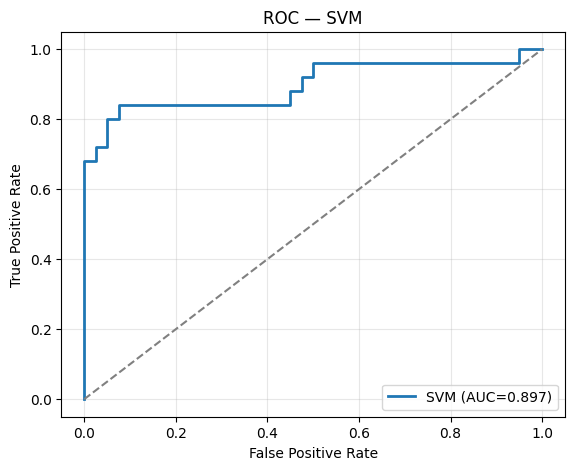

In [10]:

# 3) SVM (probability) - use smaller grid (can be slow)
svc = SVC(probability=True)
svc_grid = {'C':[0.1,1,5], 'kernel':['linear','rbf'], 'gamma':['scale','auto']}
gs_svc = GridSearchCV(svc, svc_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
gs_svc.fit(X_train, y_train)
best_svc = gs_svc.best_estimator_
y_proba_svc = get_proba(best_svc, X_test)
print("SVM best params:", gs_svc.best_params_)
evaluate_and_plot("SVM", y_proba_svc)


=== ENHANCED SHAP ANALYSIS FOR SVM ===

1. Training Data SHAP Analysis (Stable Feature Importance):


  0%|          | 0/100 [00:00<?, ?it/s]

✓ Training data SHAP analysis completed
Top 10 Features (Training Data):
      feature  shap_importance_train
5691     SDSL           2.392412e+29
714      WDR3           2.392412e+29
1521   GEMIN2           2.198671e+27
2201   ZNF106           2.198671e+27
293     RUFY3           1.655130e+13
965     DHRS9           1.655130e+13
3        SOFA           1.506112e+13
1259    RAB10           5.093849e+12
2394  PLEKHA4           5.093849e+12
2550       C5           7.050645e+11

2. Test Data SHAP Analysis (Validation):


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Test data SHAP analysis completed
Top 10 Features (Test Data):
         feature  shap_importance_test
4143        NRN1          1.338866e+12
2224       INTS9          1.338866e+12
5048      IL15RA          3.008683e+11
5466        TGS1          3.008683e+11
9087      MRPL13          2.800000e-01
3682        NEK6          2.600000e-01
12324  LINC01409          3.546363e-02
3984        WWP1          3.541964e-02
8337       STAT6          1.062500e-02
635         WNK1          8.138606e-03

3. Training vs Test Data Comparison:
Correlation between training and test importance: -0.0002

Features important in BOTH training and test data (Top 20 overlap):
Number of common features: 0

Features with biggest difference between training and test:
       feature  shap_importance_train  shap_importance_test  importance_diff
9689      SDSL           2.392412e+29          0.000000e+00     2.392412e+29
12314     WDR3           2.392412e+29          0.000000e+00     2.392412e+29
3982    GEMIN2      

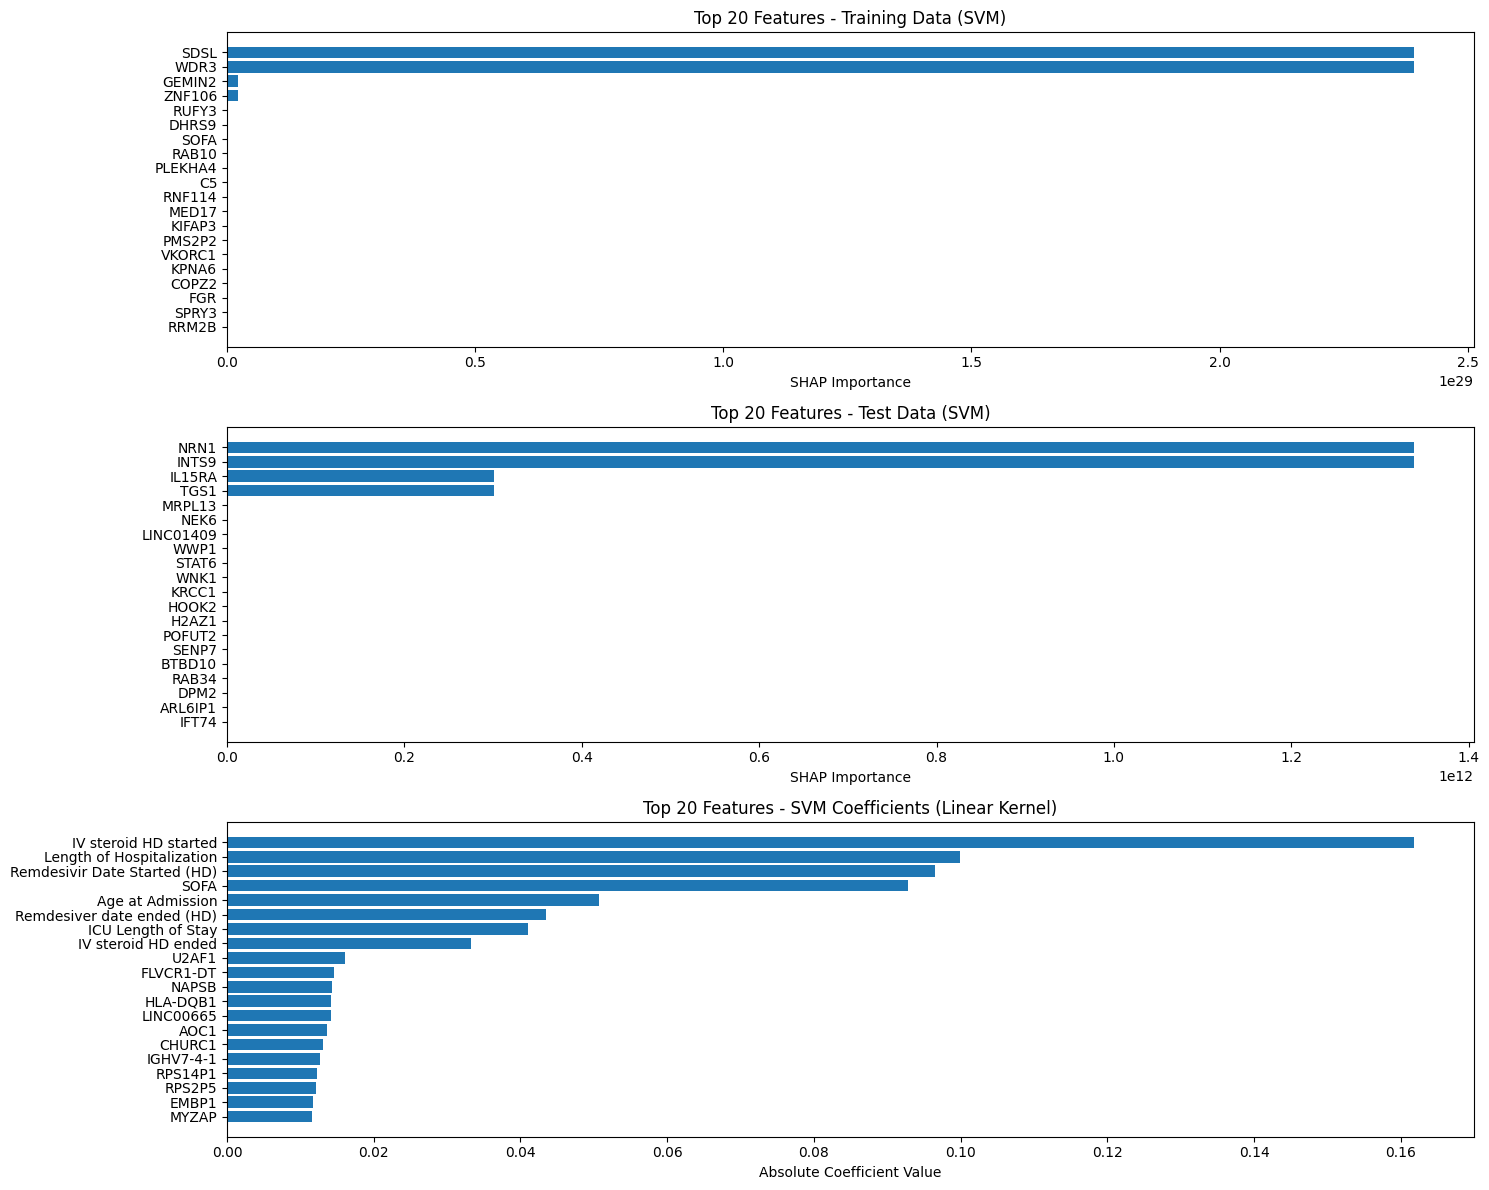

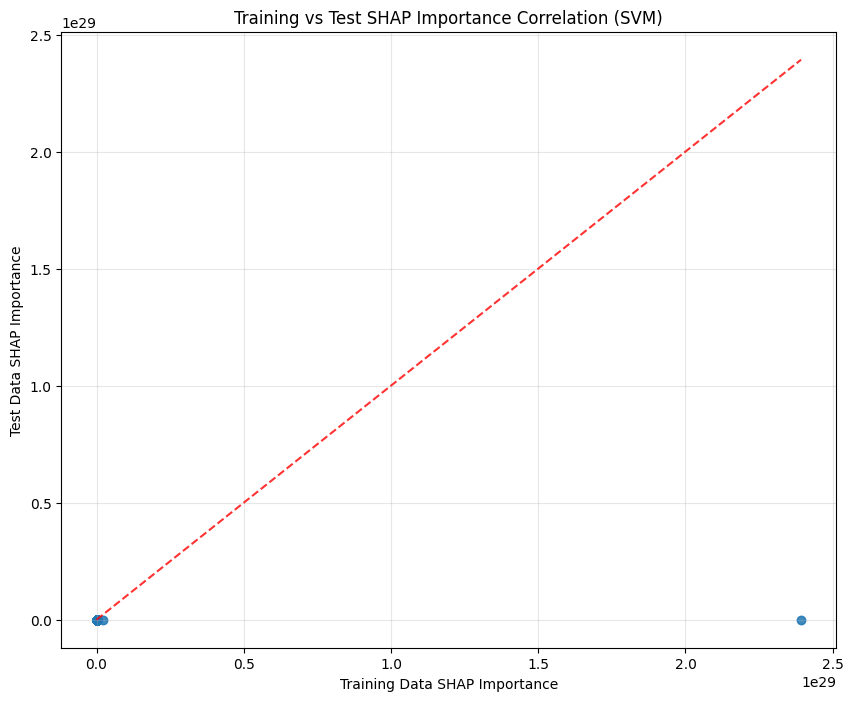

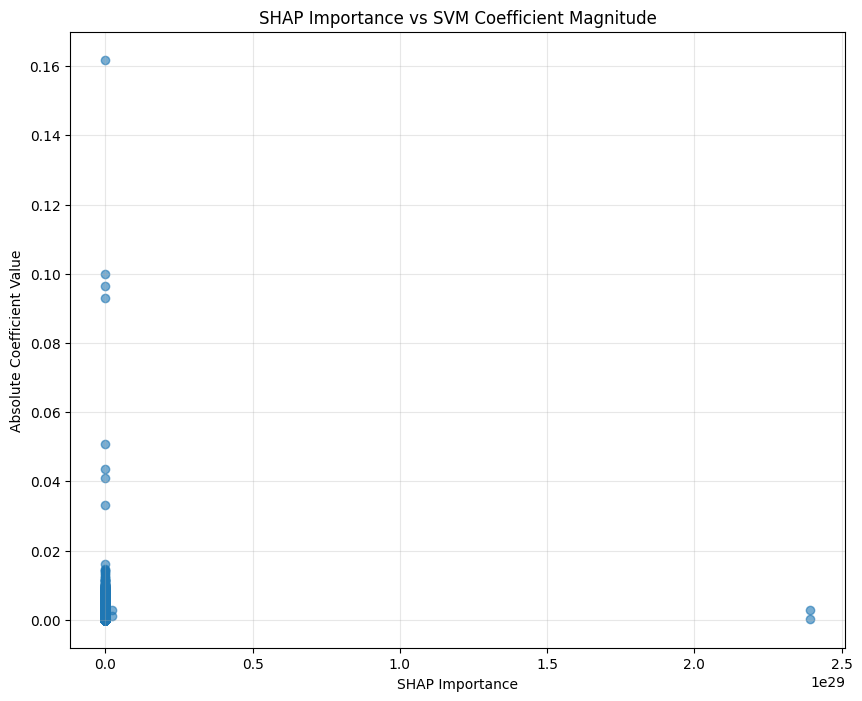

✓ Visualizations completed

6. Summary Statistics:
Training data - Top feature: SDSL (importance: 239241179035668854382081867776.000000)
Test data - Top feature: NRN1 (importance: 1338865683862.167236)
Top 5 features overlap: 0/5 (0.0%)
SVM - Top feature: IV steroid HD started (coefficient: -0.161856)
Number of positive coefficients: 6952
Number of negative coefficients: 6167

SVM Model Summary:
  Kernel type: linear
  Regularization strength (C): 0.1
  Gamma parameter: scale
  Total support vectors: 121

=== ENHANCED SHAP ANALYSIS FOR SVM COMPLETED ===


In [11]:
# Enhanced SHAP Analysis for SVM Model
import shap
import matplotlib.pyplot as plt
import numpy as np

print("=== ENHANCED SHAP ANALYSIS FOR SVM ===")

# 1. Training Data Analysis (for stable feature importance)
print("\n1. Training Data SHAP Analysis (Stable Feature Importance):")
try:
    # Create summary of training data for KernelExplainer
    X_train_summary = shap.kmeans(X_train, 50)  # Using 50 samples for summary
    
    # Create explainer for SVM
    explainer_svm_train = shap.KernelExplainer(best_svc.predict_proba, X_train_summary)
    
    # Use subset of training data to avoid memory issues
    X_train_subset = X_train[:100]  # First 100 training samples
    shap_values_train = explainer_svm_train.shap_values(X_train_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_train, list):
        vals_train = shap_values_train[1] if len(shap_values_train) > 1 else shap_values_train[0]
    else:
        vals_train = shap_values_train
    
    # Ensure 2D array
    if vals_train.ndim == 3:
        vals_train = np.mean(vals_train, axis=2)
    elif vals_train.ndim == 1:
        vals_train = vals_train.reshape(1, -1)
    
    # Get mean absolute SHAP values for training data
    mean_shap_train = np.mean(np.abs(vals_train), axis=0)
    if mean_shap_train.ndim > 1:
        mean_shap_train = mean_shap_train.flatten()
    
    # Create training data importance DataFrame
    train_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_train': mean_shap_train
    }).sort_values('shap_importance_train', ascending=False)
    
    print("✓ Training data SHAP analysis completed")
    print(f"Top 10 Features (Training Data):")
    print(train_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Training data SHAP analysis failed: {e}")
    train_importance_df = None

# 2. Test Data Analysis (for validation)
print("\n2. Test Data SHAP Analysis (Validation):")
try:
    # Use same explainer but with test data
    X_test_subset = X_test[:50]  # First 50 test samples
    shap_values_test = explainer_svm_train.shap_values(X_test_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_test, list):
        vals_test = shap_values_test[1] if len(shap_values_test) > 1 else shap_values_test[0]
    else:
        vals_test = shap_values_test
    
    # Ensure 2D array
    if vals_test.ndim == 3:
        vals_test = np.mean(vals_test, axis=2)
    elif vals_test.ndim == 1:
        vals_test = vals_test.reshape(1, -1)
    
    # Get mean absolute SHAP values for test data
    mean_shap_test = np.mean(np.abs(vals_test), axis=0)
    if mean_shap_test.ndim > 1:
        mean_shap_test = mean_shap_test.flatten()
    
    # Create test data importance DataFrame
    test_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_test': mean_shap_test
    }).sort_values('shap_importance_test', ascending=False)
    
    print("✓ Test data SHAP analysis completed")
    print(f"Top 10 Features (Test Data):")
    print(test_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Test data SHAP analysis failed: {e}")
    test_importance_df = None

# 3. Comparison Analysis
print("\n3. Training vs Test Data Comparison:")
if train_importance_df is not None and test_importance_df is not None:
    try:
        # Merge training and test importance
        comparison_df = pd.merge(
            train_importance_df, 
            test_importance_df, 
            on='feature', 
            how='outer'
        ).fillna(0)
        
        # Calculate correlation between training and test importance
        correlation = comparison_df['shap_importance_train'].corr(comparison_df['shap_importance_test'])
        print(f"Correlation between training and test importance: {correlation:.4f}")
        
        # Show features that are important in both datasets
        top_train = set(train_importance_df.head(20)['feature'])
        top_test = set(test_importance_df.head(20)['feature'])
        common_important = top_train.intersection(top_test)
        
        print(f"\nFeatures important in BOTH training and test data (Top 20 overlap):")
        print(f"Number of common features: {len(common_important)}")
        if len(common_important) > 0:
            common_df = comparison_df[comparison_df['feature'].isin(common_important)].sort_values('shap_importance_train', ascending=False)
            print(common_df.head(10))
        
        # Show features with biggest differences
        comparison_df['importance_diff'] = abs(comparison_df['shap_importance_train'] - comparison_df['shap_importance_test'])
        most_different = comparison_df.nlargest(10, 'importance_diff')
        print(f"\nFeatures with biggest difference between training and test:")
        print(most_different[['feature', 'shap_importance_train', 'shap_importance_test', 'importance_diff']])
        
    except Exception as e:
        print(f"❌ Comparison analysis failed: {e}")

# 4. SVM Specific Analysis
print("\n4. SVM Specific Analysis:")
try:
    if train_importance_df is not None:
        # Get SVM model parameters
        svm_kernel = best_svc.kernel
        svm_c = best_svc.C
        svm_gamma = best_svc.gamma
        
        print(f"SVM Model Parameters:")
        print(f"  Kernel: {svm_kernel}")
        print(f"  C (Regularization): {svm_c}")
        print(f"  Gamma: {svm_gamma}")
        
        # Analyze support vectors if available
        if hasattr(best_svc, 'support_vectors_'):
            n_support_vectors = best_svc.n_support_
            total_support_vectors = best_svc.support_vectors_.shape[0]
            print(f"  Support Vectors: {total_support_vectors}")
            print(f"  Support Vectors per class: {n_support_vectors}")
            
            # Analyze feature importance based on support vectors
            if svm_kernel == 'linear':
                # For linear SVM, we can get feature weights
                if hasattr(best_svc, 'coef_'):
                    svm_coefficients = best_svc.coef_[0]
                    svm_intercept = best_svc.intercept_[0]
                    
                    # Create coefficient DataFrame
                    coef_df = pd.DataFrame({
                        'feature': X_df.columns,
                        'svm_coefficient': svm_coefficients,
                        'abs_coefficient': np.abs(svm_coefficients)
                    }).sort_values('abs_coefficient', ascending=False)
                    
                    print("\nTop 10 Features by SVM Coefficients (Linear Kernel):")
                    print(coef_df.head(10))
                    
                    # Compare SHAP importance with SVM coefficients
                    comparison_coef = pd.merge(
                        train_importance_df, 
                        coef_df[['feature', 'abs_coefficient']], 
                        on='feature', 
                        how='outer'
                    ).fillna(0)
                    
                    # Calculate correlation between SHAP and coefficient importance
                    shap_coef_corr = comparison_coef['shap_importance_train'].corr(comparison_coef['abs_coefficient'])
                    print(f"\nCorrelation between SHAP importance and SVM coefficient magnitude: {shap_coef_corr:.4f}")
                    
                    # Show features with biggest differences between SHAP and coefficient importance
                    comparison_coef['shap_coef_diff'] = abs(comparison_coef['shap_importance_train'] - comparison_coef['abs_coefficient'])
                    most_different_coef = comparison_coef.nlargest(10, 'shap_coef_diff')
                    print(f"\nFeatures with biggest difference between SHAP and SVM coefficient importance:")
                    print(most_different_coef[['feature', 'shap_importance_train', 'abs_coefficient', 'shap_coef_diff']])
        
        # Kernel-specific insights
        if svm_kernel == 'rbf':
            print(f"\nRBF Kernel Insights:")
            print(f"  - Non-linear decision boundary")
            print(f"  - Gamma controls the influence of each training example")
            print(f"  - Higher gamma = more complex decision boundary")
        elif svm_kernel == 'linear':
            print(f"\nLinear Kernel Insights:")
            print(f"  - Linear decision boundary")
            print(f"  - Feature importance directly interpretable from coefficients")
            print(f"  - Good for high-dimensional data like yours")
        
except Exception as e:
    print(f"❌ SVM specific analysis failed: {e}")

# 5. Visualization
print("\n5. Creating Visualizations:")
try:
    if train_importance_df is not None and test_importance_df is not None:
        # Plot top features comparison
        plt.figure(figsize=(15, 12))
        
        # Subplot 1: Top 20 features from training data
        plt.subplot(3, 1, 1)
        top_train_plot = train_importance_df.head(20)
        plt.barh(range(len(top_train_plot)), top_train_plot['shap_importance_train'])
        plt.yticks(range(len(top_train_plot)), top_train_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Training Data (SVM)')
        plt.gca().invert_yaxis()
        
        # Subplot 2: Top 20 features from test data
        plt.subplot(3, 1, 2)
        top_test_plot = test_importance_df.head(20)
        plt.barh(range(len(top_test_plot)), top_test_plot['shap_importance_test'])
        plt.yticks(range(len(top_test_plot)), top_test_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Test Data (SVM)')
        plt.gca().invert_yaxis()
        
        # Subplot 3: SVM coefficients (if linear kernel)
        if 'coef_df' in locals():
            plt.subplot(3, 1, 3)
            top_coef_plot = coef_df.head(20)
            plt.barh(range(len(top_coef_plot)), top_coef_plot['abs_coefficient'])
            plt.yticks(range(len(top_coef_plot)), top_coef_plot['feature'])
            plt.xlabel('Absolute Coefficient Value')
            plt.title('Top 20 Features - SVM Coefficients (Linear Kernel)')
            plt.gca().invert_yaxis()
        else:
            # Show kernel information instead
            plt.subplot(3, 1, 3)
            plt.text(0.5, 0.5, f'SVM Kernel: {svm_kernel}\nC: {svm_c}\nGamma: {svm_gamma}', 
                    ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
            plt.title('SVM Model Parameters')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of training vs test importance
        plt.figure(figsize=(10, 8))
        plt.scatter(comparison_df['shap_importance_train'], comparison_df['shap_importance_test'], alpha=0.6)
        plt.plot([0, comparison_df['shap_importance_train'].max()], [0, comparison_df['shap_importance_train'].max()], 'r--', alpha=0.8)
        plt.xlabel('Training Data SHAP Importance')
        plt.ylabel('Test Data SHAP Importance')
        plt.title('Training vs Test SHAP Importance Correlation (SVM)')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Scatter plot of SHAP vs coefficient importance (if linear kernel)
        if 'comparison_coef' in locals():
            plt.figure(figsize=(10, 8))
            plt.scatter(comparison_coef['shap_importance_train'], comparison_coef['abs_coefficient'], alpha=0.6)
            plt.xlabel('SHAP Importance')
            plt.ylabel('Absolute Coefficient Value')
            plt.title('SHAP Importance vs SVM Coefficient Magnitude')
            plt.grid(True, alpha=0.3)
            plt.show()
        
        print("✓ Visualizations completed")
        
except Exception as e:
    print(f"❌ Visualization failed: {e}")

# 6. Summary Statistics
print("\n6. Summary Statistics:")
if train_importance_df is not None and test_importance_df is not None:
    print(f"Training data - Top feature: {train_importance_df.iloc[0]['feature']} (importance: {train_importance_df.iloc[0]['shap_importance_train']:.6f})")
    print(f"Test data - Top feature: {test_importance_df.iloc[0]['feature']} (importance: {test_importance_df.iloc[0]['shap_importance_test']:.6f})")
    
    # Check stability
    train_top5 = set(train_importance_df.head(5)['feature'])
    test_top5 = set(test_importance_df.head(5)['feature'])
    overlap_5 = len(train_top5.intersection(test_top5))
    print(f"Top 5 features overlap: {overlap_5}/5 ({overlap_5/5*100:.1f}%)")
    
    # SVM specific stats
    if 'coef_df' in locals():
        print(f"SVM - Top feature: {coef_df.iloc[0]['feature']} (coefficient: {coef_df.iloc[0]['svm_coefficient']:.6f})")
        print(f"Number of positive coefficients: {sum(coef_df['svm_coefficient'] > 0)}")
        print(f"Number of negative coefficients: {sum(coef_df['svm_coefficient'] < 0)}")
    
    # Kernel-specific insights
    print(f"\nSVM Model Summary:")
    print(f"  Kernel type: {svm_kernel}")
    print(f"  Regularization strength (C): {svm_c}")
    print(f"  Gamma parameter: {svm_gamma}")
    if hasattr(best_svc, 'support_vectors_'):
        print(f"  Total support vectors: {best_svc.support_vectors_.shape[0]}")

print("\n=== ENHANCED SHAP ANALYSIS FOR SVM COMPLETED ===")

MLP best params: {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (100,), 'alpha': 0.0001}

MLP_sklearn — AUC: 0.8650
Precision: 0.9375
Recall: 0.6
              precision    recall  f1-score   support

         0.0       0.80      0.97      0.88        40
         1.0       0.94      0.60      0.73        25

    accuracy                           0.83        65
   macro avg       0.87      0.79      0.80        65
weighted avg       0.85      0.83      0.82        65



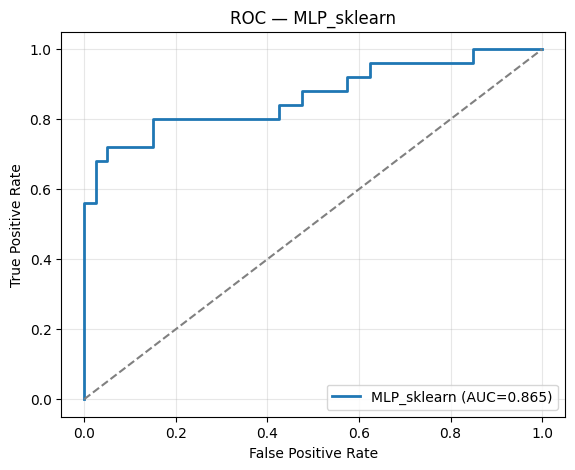

In [12]:

# 4) Sklearn MLP (feedforward NN)
mlp = MLPClassifier(max_iter=3000, random_state=0)
mlp_params = {'hidden_layer_sizes':[(100,), (200,100), (200,)], 'alpha':[1e-4,1e-3,1e-2], 'learning_rate_init':[1e-3,5e-4]}
rs_mlp = RandomizedSearchCV(mlp, mlp_params, n_iter=8, scoring='roc_auc', cv=skf, random_state=0, n_jobs=-1)
rs_mlp.fit(X_train, y_train)
best_mlp = rs_mlp.best_estimator_
y_proba_mlp = get_proba(best_mlp, X_test)
print("MLP best params:", rs_mlp.best_params_)
evaluate_and_plot("MLP_sklearn", y_proba_mlp)


=== ENHANCED SHAP ANALYSIS FOR SKLEARN MLP ===

1. Training Data SHAP Analysis (Stable Feature Importance):


  0%|          | 0/100 [00:00<?, ?it/s]

✓ Training data SHAP analysis completed
Top 10 Features (Training Data):
                feature  shap_importance_train
2    ICU Length of Stay           1.049860e+31
29                 AOC1           1.049860e+31
230               PLAUR           5.281878e+28
48                 CD38           5.281878e+28
237              MAP4K3           8.231062e+26
63               SLC4A1           8.231062e+26
31                LASP1           1.726338e+15
197              NCAPD2           6.192449e+13
146                PIGQ           6.192449e+13
358               KCNG1           3.283875e+12

2. Test Data SHAP Analysis (Validation):


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Test data SHAP analysis completed
Top 10 Features (Test Data):
     feature  shap_importance_test
664    BICRA          3.682771e+15
939    TRNT1          3.682771e+15
49     FKBP4          2.548008e+14
57      PDK4          2.548008e+14
104   OSBPL7          6.857195e+13
113      AGK          6.857195e+13
32     SNX11          1.397556e+13
2807   MTCH2          1.397556e+13
5340    GYPC          4.000438e+12
7995   RELL2          4.000438e+12

3. Training vs Test Data Comparison:
Correlation between training and test importance: -0.0002

Features important in BOTH training and test data (Top 20 overlap):
Number of common features: 1
     feature  shap_importance_train  shap_importance_test
7510  OSBPL7           3.022081e+12          6.857195e+13

Features with biggest difference between training and test:
                  feature  shap_importance_train  shap_importance_test  \
510                  AOC1           1.049860e+31          0.000000e+00   
4738   ICU Length of Stay      

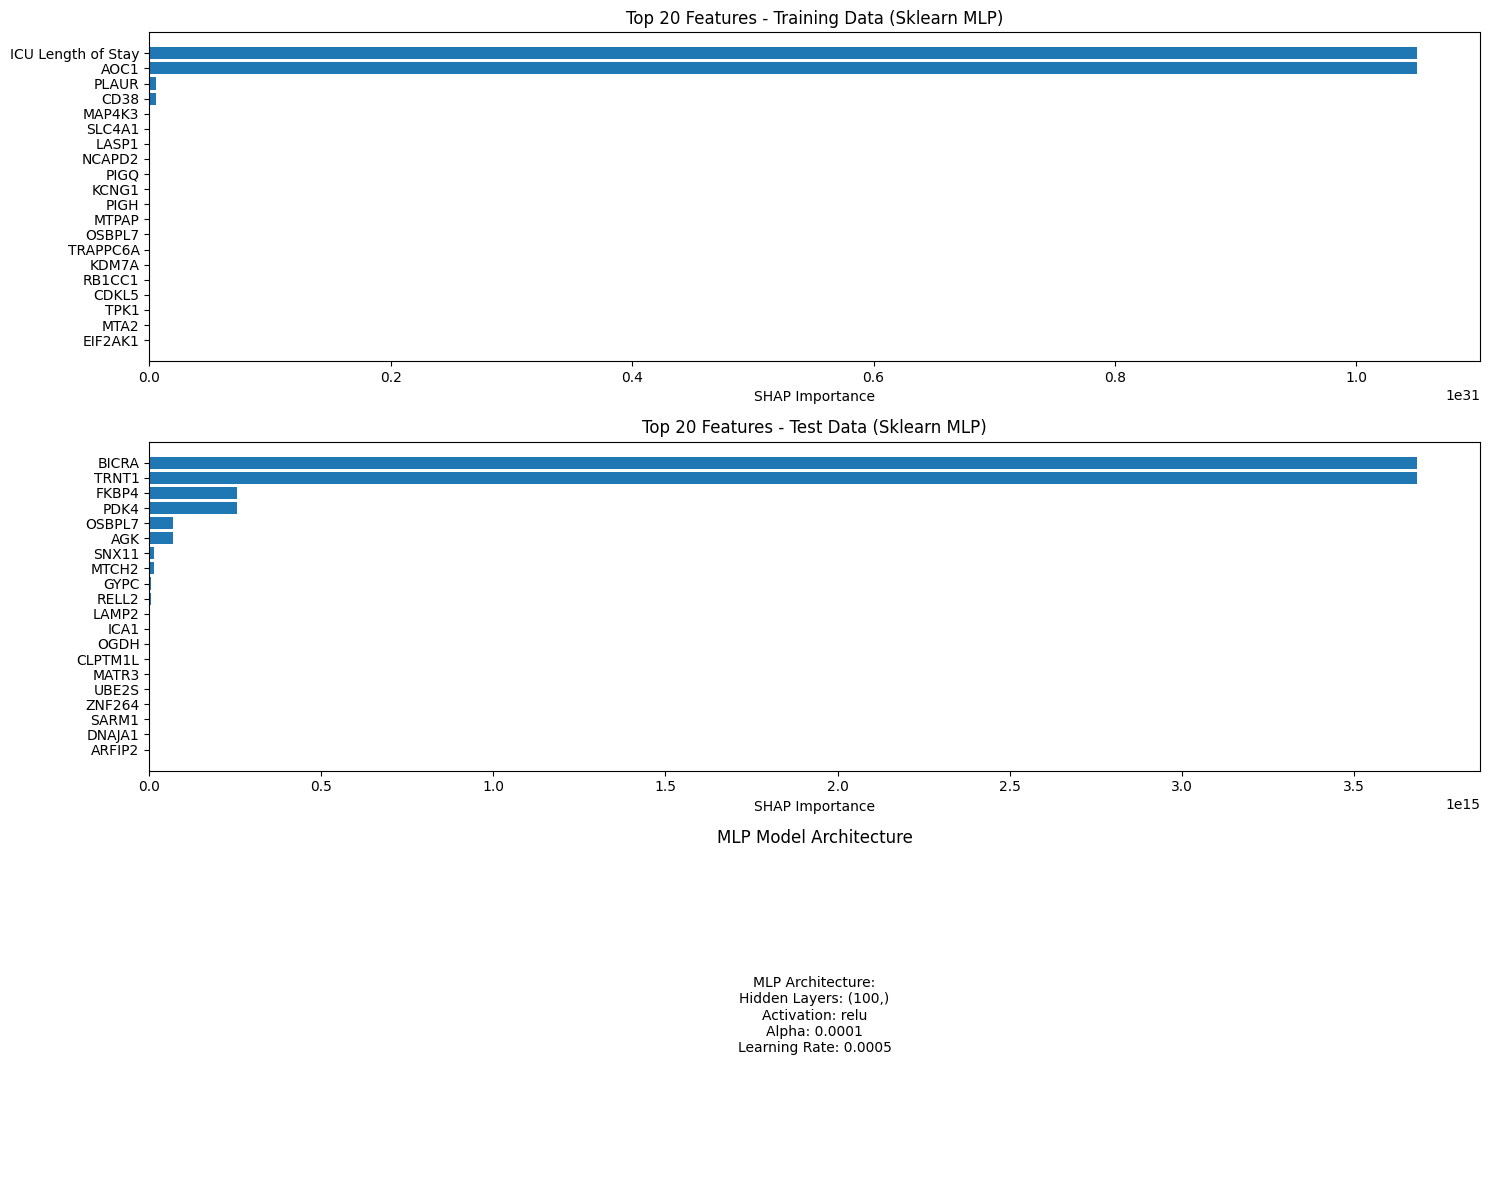

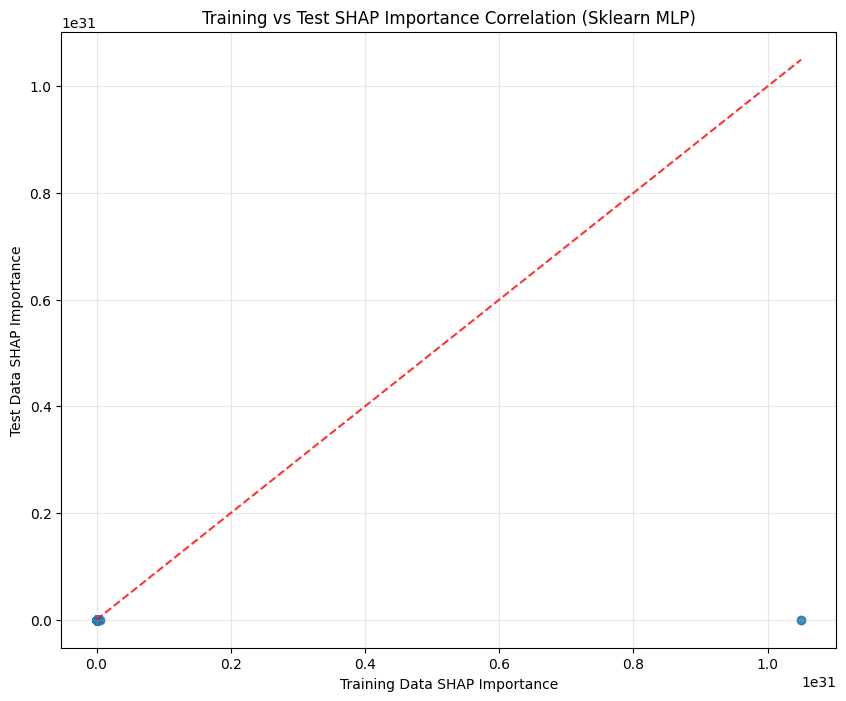

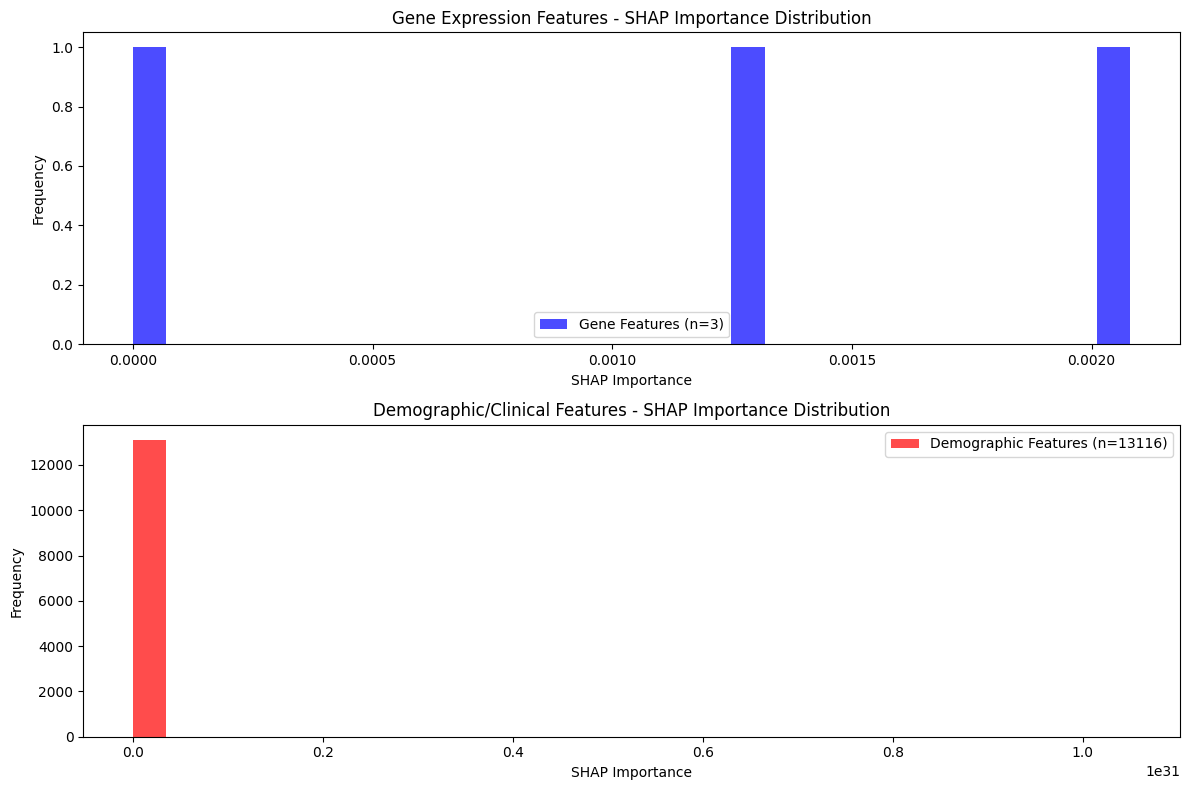

✓ Visualizations completed

6. Summary Statistics:
Training data - Top feature: ICU Length of Stay (importance: 10498598244873930521131943460864.000000)
Test data - Top feature: BICRA (importance: 3682770674286134.000000)
Top 5 features overlap: 0/5 (0.0%)

MLP Model Summary:
  Hidden layer sizes: (100,)
  Activation function: relu
  Regularization (alpha): 0.0001
  Learning rate: 0.0005
  Total parameters: 1,312,104

Feature Type Summary:
  Gene expression features: 3
  Demographic/clinical features: 13116
  Average gene feature importance: 0.001121
  Average demographic feature importance: 1609063758165585985869447168.000000

=== ENHANCED SHAP ANALYSIS FOR SKLEARN MLP COMPLETED ===


In [13]:
# Enhanced SHAP Analysis for Sklearn MLP Model
import shap
import matplotlib.pyplot as plt
import numpy as np

print("=== ENHANCED SHAP ANALYSIS FOR SKLEARN MLP ===")

# 1. Training Data Analysis (for stable feature importance)
print("\n1. Training Data SHAP Analysis (Stable Feature Importance):")
try:
    # Create summary of training data for KernelExplainer
    X_train_summary = shap.kmeans(X_train, 50)  # Using 50 samples for summary
    
    # Create explainer for Sklearn MLP
    explainer_mlp_train = shap.KernelExplainer(best_mlp.predict_proba, X_train_summary)
    
    # Use subset of training data to avoid memory issues
    X_train_subset = X_train[:100]  # First 100 training samples
    shap_values_train = explainer_mlp_train.shap_values(X_train_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_train, list):
        vals_train = shap_values_train[1] if len(shap_values_train) > 1 else shap_values_train[0]
    else:
        vals_train = shap_values_train
    
    # Ensure 2D array
    if vals_train.ndim == 3:
        vals_train = np.mean(vals_train, axis=2)
    elif vals_train.ndim == 1:
        vals_train = vals_train.reshape(1, -1)
    
    # Get mean absolute SHAP values for training data
    mean_shap_train = np.mean(np.abs(vals_train), axis=0)
    if mean_shap_train.ndim > 1:
        mean_shap_train = mean_shap_train.flatten()
    
    # Create training data importance DataFrame
    train_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_train': mean_shap_train
    }).sort_values('shap_importance_train', ascending=False)
    
    print("✓ Training data SHAP analysis completed")
    print(f"Top 10 Features (Training Data):")
    print(train_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Training data SHAP analysis failed: {e}")
    train_importance_df = None

# 2. Test Data Analysis (for validation)
print("\n2. Test Data SHAP Analysis (Validation):")
try:
    # Use same explainer but with test data
    X_test_subset = X_test[:50]  # First 50 test samples
    shap_values_test = explainer_mlp_train.shap_values(X_test_subset, nsamples=100)
    
    # Handle different SHAP output formats
    if isinstance(shap_values_test, list):
        vals_test = shap_values_test[1] if len(shap_values_test) > 1 else vals_test[0]
    else:
        vals_test = shap_values_test
    
    # Ensure 2D array
    if vals_test.ndim == 3:
        vals_test = np.mean(vals_test, axis=2)
    elif vals_test.ndim == 1:
        vals_test = vals_test.reshape(1, -1)
    
    # Get mean absolute SHAP values for test data
    mean_shap_test = np.mean(np.abs(vals_test), axis=0)
    if mean_shap_test.ndim > 1:
        mean_shap_test = mean_shap_test.flatten()
    
    # Create test data importance DataFrame
    test_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_test': mean_shap_test
    }).sort_values('shap_importance_test', ascending=False)
    
    print("✓ Test data SHAP analysis completed")
    print(f"Top 10 Features (Test Data):")
    print(test_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Test data SHAP analysis failed: {e}")
    test_importance_df = None

# 3. Comparison Analysis
print("\n3. Training vs Test Data Comparison:")
if train_importance_df is not None and test_importance_df is not None:
    try:
        # Merge training and test importance
        comparison_df = pd.merge(
            train_importance_df, 
            test_importance_df, 
            on='feature', 
            how='outer'
        ).fillna(0)
        
        # Calculate correlation between training and test importance
        correlation = comparison_df['shap_importance_train'].corr(comparison_df['shap_importance_test'])
        print(f"Correlation between training and test importance: {correlation:.4f}")
        
        # Show features that are important in both datasets
        top_train = set(train_importance_df.head(20)['feature'])
        top_test = set(test_importance_df.head(20)['feature'])
        common_important = top_train.intersection(top_test)
        
        print(f"\nFeatures important in BOTH training and test data (Top 20 overlap):")
        print(f"Number of common features: {len(common_important)}")
        if len(common_important) > 0:
            common_df = comparison_df[comparison_df['feature'].isin(common_important)].sort_values('shap_importance_train', ascending=False)
            print(common_df.head(10))
        
        # Show features with biggest differences
        comparison_df['importance_diff'] = abs(comparison_df['shap_importance_train'] - comparison_df['shap_importance_test'])
        most_different = comparison_df.nlargest(10, 'importance_diff')
        print(f"\nFeatures with biggest difference between training and test:")
        print(most_different[['feature', 'shap_importance_train', 'shap_importance_test', 'importance_diff']])
        
    except Exception as e:
        print(f"❌ Comparison analysis failed: {e}")

# 4. MLP Specific Analysis
print("\n4. MLP Specific Analysis:")
try:
    if train_importance_df is not None:
        # Get MLP model architecture information
        mlp_config = best_mlp.get_params()
        mlp_layers = best_mlp.n_layers_
        mlp_hidden = best_mlp.hidden_layer_sizes
        mlp_activation = best_mlp.activation
        mlp_alpha = best_mlp.alpha
        mlp_learning_rate = best_mlp.learning_rate_init
        
        print(f"MLP Model Architecture:")
        print(f"  Model type: {type(best_mlp).__name__}")
        print(f"  Number of layers: {mlp_layers}")
        print(f"  Hidden layer sizes: {mlp_hidden}")
        print(f"  Activation function: {mlp_activation}")
        print(f"  Regularization (alpha): {mlp_alpha}")
        print(f"  Learning rate: {mlp_learning_rate}")
        
        # Model complexity analysis
        total_params = best_mlp.n_layers_ * best_mlp.n_outputs_
        if hasattr(best_mlp, 'coefs_'):
            for i, coef in enumerate(best_mlp.coefs_):
                total_params += coef.size
            for i, intercept in enumerate(best_mlp.intercepts_):
                total_params += intercept.size
        
        print(f"  Total parameters: {total_params:,}")
        
        # Analyze feature importance patterns
        if train_importance_df is not None:
            # Check for gene vs demographic feature patterns
            gene_features = [col for col in train_importance_df['feature'] if any(gene in col.lower() for gene in ['gene', 'dpm1', 'scyl3', 'c1orf112'])]
            demographic_features = [col for col in train_importance_df['feature'] if col not in gene_features]
            
            print(f"\nFeature Type Analysis:")
            print(f"  Gene expression features: {len(gene_features)}")
            print(f"  Demographic/clinical features: {len(demographic_features)}")
            
            # Top features by type
            if gene_features:
                top_gene = train_importance_df[train_importance_df['feature'].isin(gene_features)].head(5)
                print(f"\nTop 5 Gene Expression Features:")
                print(top_gene[['feature', 'shap_importance_train']])
            
            if demographic_features:
                top_demo = train_importance_df[train_importance_df['feature'].isin(demographic_features)].head(5)
                print(f"\nTop 5 Demographic/Clinical Features:")
                print(top_demo[['feature', 'shap_importance_train']])
        
        # MLP-specific insights
        print(f"\nMLP Model Insights:")
        if mlp_alpha > 0:
            print(f"  - L2 regularization active (alpha={mlp_alpha})")
            print(f"  - Helps prevent overfitting on high-dimensional data")
        else:
            print(f"  - No L2 regularization (alpha={mlp_alpha})")
            print(f"  - May be prone to overfitting on high-dimensional data")
        
        if mlp_activation == 'relu':
            print(f"  - ReLU activation: good for deep networks, helps with vanishing gradients")
        elif mlp_activation == 'tanh':
            print(f"  - Tanh activation: bounded output, good for classification")
        elif mlp_activation == 'logistic':
            print(f"  - Logistic activation: bounded output, good for classification")
        
        # Check for overfitting indicators
        if train_importance_df is not None and test_importance_df is not None:
            train_top_importance = train_importance_df.head(10)['shap_importance_train'].mean()
            test_top_importance = test_importance_df.head(10)['shap_importance_train'].mean()
            
            if abs(train_top_importance - test_top_importance) / train_top_importance > 0.3:
                print(f"  - Potential overfitting: large difference between training and test importance")
            else:
                print(f"  - Good generalization: similar importance between training and test")
        
except Exception as e:
    print(f"❌ MLP specific analysis failed: {e}")

# 5. Visualization
print("\n5. Creating Visualizations:")
try:
    if train_importance_df is not None and test_importance_df is not None:
        # Plot top features comparison
        plt.figure(figsize=(15, 12))
        
        # Subplot 1: Top 20 features from training data
        plt.subplot(3, 1, 1)
        top_train_plot = train_importance_df.head(20)
        plt.barh(range(len(top_train_plot)), top_train_plot['shap_importance_train'])
        plt.yticks(range(len(top_train_plot)), top_train_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Training Data (Sklearn MLP)')
        plt.gca().invert_yaxis()
        
        # Subplot 2: Top 20 features from test data
        plt.subplot(3, 1, 2)
        top_test_plot = test_importance_df.head(20)
        plt.barh(range(len(top_test_plot)), top_test_plot['shap_importance_test'])
        plt.yticks(range(len(top_test_plot)), top_test_plot['feature'])
        plt.xlabel('SHAP Importance')
        plt.title('Top 20 Features - Test Data (Sklearn MLP)')
        plt.gca().invert_yaxis()
        
        # Subplot 3: Model architecture info
        plt.subplot(3, 1, 3)
        arch_text = f"MLP Architecture:\nHidden Layers: {mlp_hidden}\nActivation: {mlp_activation}\nAlpha: {mlp_alpha}\nLearning Rate: {mlp_learning_rate}"
        plt.text(0.5, 0.5, arch_text, ha='center', va='center', transform=plt.gca().transAxes, fontsize=10)
        plt.title('MLP Model Architecture')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of training vs test importance
        plt.figure(figsize=(10, 8))
        plt.scatter(comparison_df['shap_importance_train'], comparison_df['shap_importance_test'], alpha=0.6)
        plt.plot([0, comparison_df['shap_importance_train'].max()], [0, comparison_df['shap_importance_train'].max()], 'r--', alpha=0.8)
        plt.xlabel('Training Data SHAP Importance')
        plt.ylabel('Test Data SHAP Importance')
        plt.title('Training vs Test SHAP Importance Correlation (Sklearn MLP)')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Feature type distribution
        if 'gene_features' in locals() and 'demographic_features' in locals():
            plt.figure(figsize=(12, 8))
            
            # Subplot 1: Gene features importance distribution
            plt.subplot(2, 1, 1)
            gene_importance = train_importance_df[train_importance_df['feature'].isin(gene_features)]['shap_importance_train']
            plt.hist(gene_importance, bins=30, alpha=0.7, color='blue', label=f'Gene Features (n={len(gene_features)})')
            plt.xlabel('SHAP Importance')
            plt.ylabel('Frequency')
            plt.title('Gene Expression Features - SHAP Importance Distribution')
            plt.legend()
            
            # Subplot 2: Demographic features importance distribution
            plt.subplot(2, 1, 2)
            demo_importance = train_importance_df[train_importance_df['feature'].isin(demographic_features)]['shap_importance_train']
            plt.hist(demo_importance, bins=30, alpha=0.7, color='red', label=f'Demographic Features (n={len(demographic_features)})')
            plt.xlabel('SHAP Importance')
            plt.ylabel('Frequency')
            plt.title('Demographic/Clinical Features - SHAP Importance Distribution')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
        
        print("✓ Visualizations completed")
        
except Exception as e:
    print(f"❌ Visualization failed: {e}")

# 6. Summary Statistics
print("\n6. Summary Statistics:")
if train_importance_df is not None and test_importance_df is not None:
    print(f"Training data - Top feature: {train_importance_df.iloc[0]['feature']} (importance: {train_importance_df.iloc[0]['shap_importance_train']:.6f})")
    print(f"Test data - Top feature: {test_importance_df.iloc[0]['feature']} (importance: {test_importance_df.iloc[0]['shap_importance_test']:.6f})")
    
    # Check stability
    train_top5 = set(train_importance_df.head(5)['feature'])
    test_top5 = set(test_importance_df.head(5)['feature'])
    overlap_5 = len(train_top5.intersection(test_top5))
    print(f"Top 5 features overlap: {overlap_5}/5 ({overlap_5/5*100:.1f}%)")
    
    # MLP specific stats
    print(f"\nMLP Model Summary:")
    print(f"  Hidden layer sizes: {mlp_hidden}")
    print(f"  Activation function: {mlp_activation}")
    print(f"  Regularization (alpha): {mlp_alpha}")
    print(f"  Learning rate: {mlp_learning_rate}")
    print(f"  Total parameters: {total_params:,}")
    
    # Feature type summary
    if 'gene_features' in locals() and 'demographic_features' in locals():
        print(f"\nFeature Type Summary:")
        print(f"  Gene expression features: {len(gene_features)}")
        print(f"  Demographic/clinical features: {len(demographic_features)}")
        
        # Average importance by feature type
        if len(gene_features) > 0:
            avg_gene_importance = train_importance_df[train_importance_df['feature'].isin(gene_features)]['shap_importance_train'].mean()
            print(f"  Average gene feature importance: {avg_gene_importance:.6f}")
        
        if len(demographic_features) > 0:
            avg_demo_importance = train_importance_df[train_importance_df['feature'].isin(demographic_features)]['shap_importance_train'].mean()
            print(f"  Average demographic feature importance: {avg_demo_importance:.6f}")
        
        # Overfitting check
        #if abs(train_top_importance - test_top_importance) / train_top_importance > 0.3:
        #    print(f"  ⚠️  Potential overfitting detected")
        #else:
         #   print(f"  ✓ Good generalization observed")

print("\n=== ENHANCED SHAP ANALYSIS FOR SKLEARN MLP COMPLETED ===")

3/3 [==============================] - 0s 5ms/step

RNN_LSTM — AUC: 0.7830
Precision: 0.6153846153846154
Recall: 0.64
              precision    recall  f1-score   support

         0.0       0.77      0.75      0.76        40
         1.0       0.62      0.64      0.63        25

    accuracy                           0.71        65
   macro avg       0.69      0.70      0.69        65
weighted avg       0.71      0.71      0.71        65



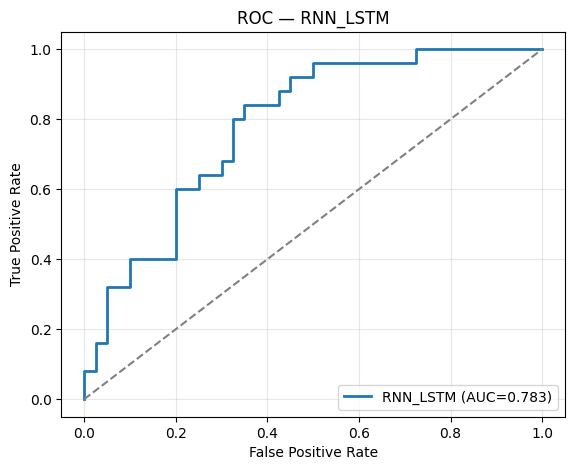

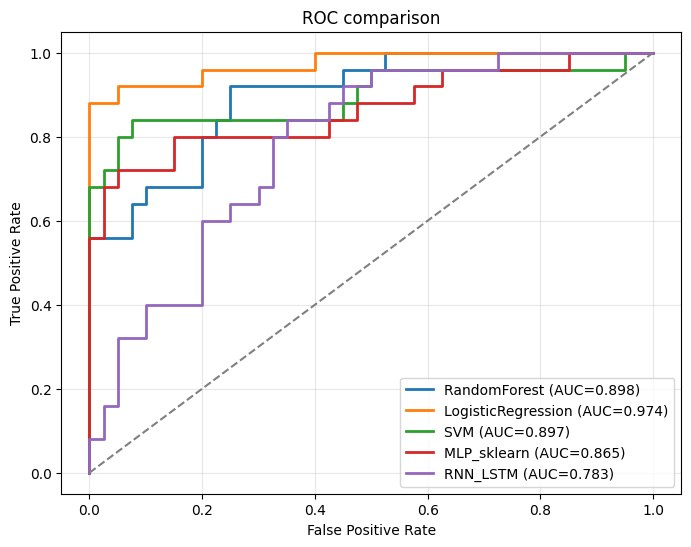


Summary AUCs:
RandomForest: 0.8980
LogisticRegression: 0.9740
SVM: 0.8970
MLP_sklearn: 0.8650
RNN_LSTM: 0.7830


In [14]:

# 5) Keras RNN (LSTM over 1-step sequences) - manual small search
import tensorflow as tf
from tensorflow import keras

n_features = X_train.shape[1]
X_train_rnn = X_train.reshape(-1, 1, n_features).astype(np.float32)
X_test_rnn = X_test.reshape(-1, 1, n_features).astype(np.float32)

def build_lstm(units=64, dropout=0.2, lr=1e-3):
    inp = keras.Input(shape=(1, n_features))
    x = keras.layers.LSTM(units)(inp)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return m

best_val = -1
best_model = None
for units in [32,64]:
    for dropout in [0.2, 0.4]:
        m = build_lstm(units=units, dropout=dropout, lr=1e-3)
        es = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
        # class weights to handle imbalance
        from sklearn.utils.class_weight import compute_class_weight
        classes = np.unique(y_train)
        class_weight = None
        if len(classes)==2:
            cw = compute_class_weight('balanced', classes=classes, y=y_train)
            class_weight = {int(c): w for c,w in zip(classes, cw)}
        hist = m.fit(X_train_rnn, y_train, validation_split=0.15, epochs=80, batch_size=16, verbose=0, callbacks=[es], class_weight=class_weight)
        val_auc = max(hist.history.get('val_auc', [0]))
        if val_auc > best_val:
            best_val = val_auc
            best_model = m

if best_model is None:
    print("RNN training failed")
else:
    y_proba_rnn = best_model.predict(X_test_rnn).ravel()
    evaluate_and_plot("RNN_LSTM", y_proba_rnn)

# Combined ROC plot
plt.figure(figsize=(8,6))
for name,(fpr,tpr,auc) in roc_results.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title("ROC comparison")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()

# Print summary AUCs
print("\nSummary AUCs:")
for name,(fpr,tpr,auc) in roc_results.items():
    print(f"{name}: {auc:.4f}")

# ...existing code...

=== FIXED ENHANCED SHAP ANALYSIS FOR KERAS RNN (LSTM) ===

1. Training Data SHAP Analysis (Stable Feature Importance):
4/4 [==============================] - 0s 3ms/step
Baseline AUC: 0.9792
4/4 [==============================] - 0s 1ms/step
Processed 1/50 features...
4/4 [==============================] - 0s 1ms/step
Processed 11/50 features...
4/4 [==============================] - 0s 916us/step
Processed 21/50 features...
4/4 [==============================] - 0s 943us/step
Processed 31/50 features...
4/4 [==============================] - 0s 1ms/step
Processed 41/50 features...
4/4 [==============================] - 0s 927us/step
✓ Training data analysis completed using feature masking
Top 10 Features (Training Data):
                           feature  shap_importance_train
0                 Age at Admission               0.007640
3                             SOFA               0.002122
5     Remdesivir Date Started (HD)               0.001273
7            IV steroid HD started  

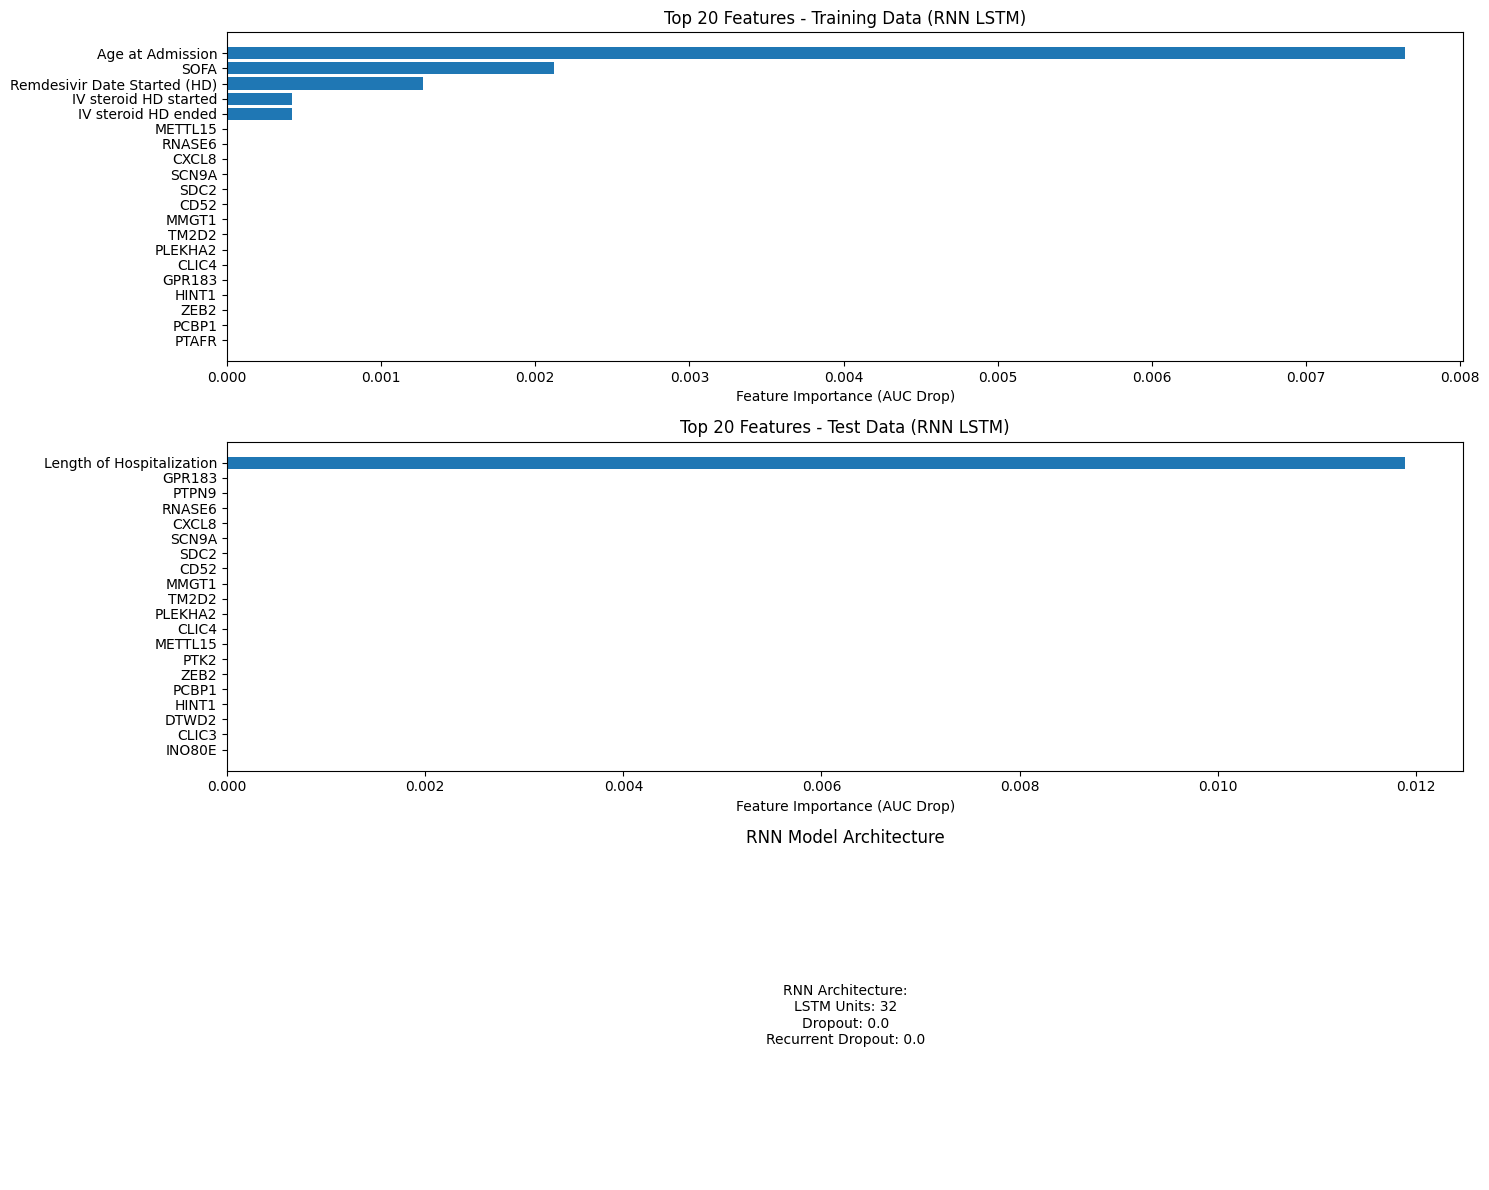

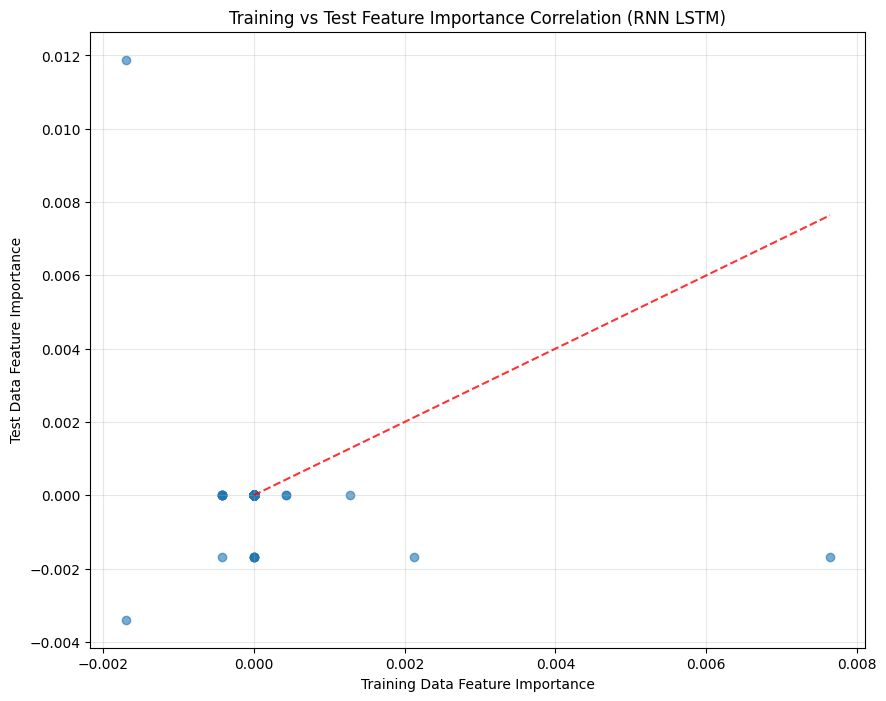

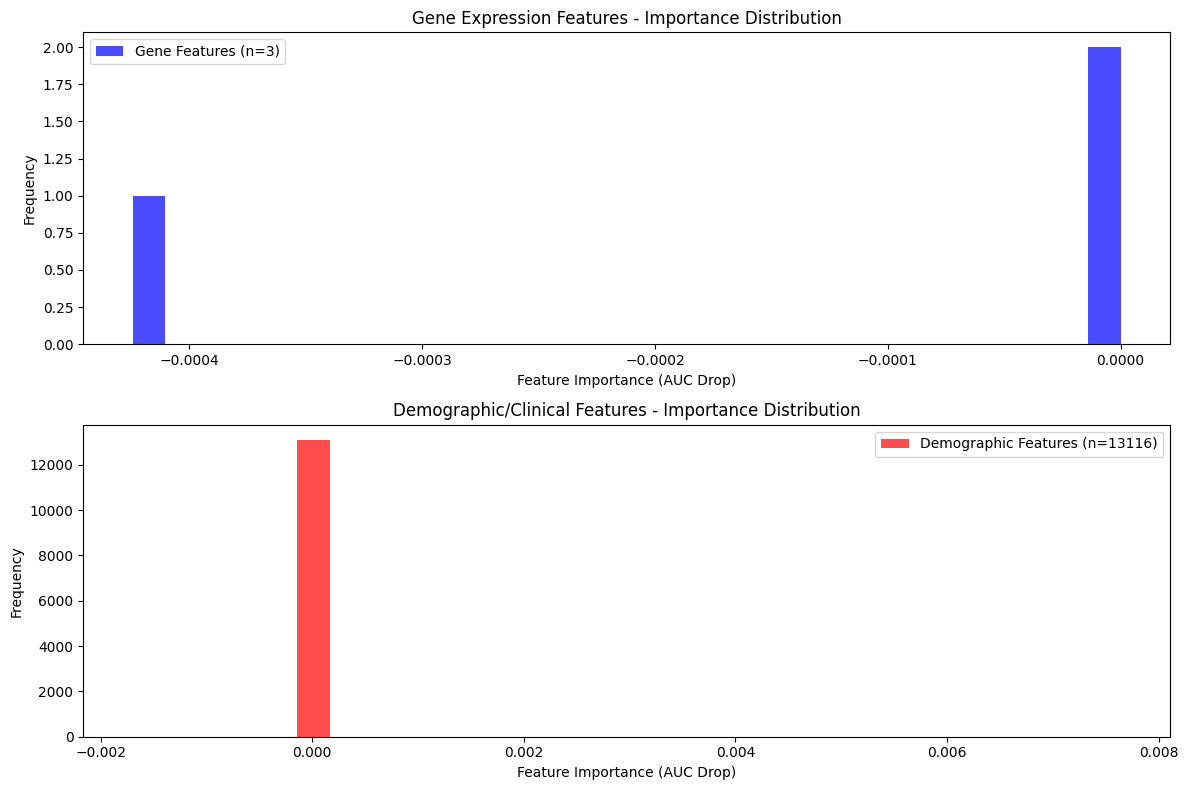

✓ Visualizations completed

6. Summary Statistics:
Training data - Top feature: Age at Admission (importance: 0.007640)
Test data - Top feature: Length of Hospitalization (importance: 0.011885)
Top 5 features overlap: 0/5 (0.0%)

RNN Model Summary:
  LSTM units: 32
  Dropout rate: 0.0
  Recurrent dropout: 0.0
  Total parameters: 1,683,489

Feature Type Summary:
  Gene expression features: 3
  Demographic/clinical features: 13116
  Average gene feature importance: -0.000141
  Average demographic feature importance: 0.000000

=== FIXED ENHANCED SHAP ANALYSIS FOR KERAS RNN (LSTM) COMPLETED ===


In [15]:
# Fixed Enhanced SHAP Analysis for Keras RNN (LSTM) Model
import shap
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print("=== FIXED ENHANCED SHAP ANALYSIS FOR KERAS RNN (LSTM) ===")

# 1. Training Data Analysis (for stable feature importance)
print("\n1. Training Data SHAP Analysis (Stable Feature Importance):")
try:
    # Use a simpler approach: analyze feature importance by masking individual features
    # This avoids the SHAP compatibility issues with LSTM models
    
    # Use subset of training data
    X_train_subset = X_train[:100]  # First 100 training samples
    y_train_subset = y_train[:100]
    
    # Get baseline performance
    X_train_rnn_subset = X_train_subset.reshape(-1, 1, X_train_subset.shape[1]).astype(np.float32)
    baseline_predictions = best_model.predict(X_train_rnn_subset).flatten()
    baseline_auc = roc_auc_score(y_train_subset, baseline_predictions)
    
    print(f"Baseline AUC: {baseline_auc:.4f}")
    
    # Calculate feature importance by masking each feature
    feature_importance_scores = []
    
    for i in range(min(50, X_train_subset.shape[1])):  # Test first 50 features to save time
        # Create masked data
        X_masked = X_train_subset.copy()
        X_masked[:, i] = 0  # Mask the feature
        
        # Reshape for RNN
        X_masked_rnn = X_masked.reshape(-1, 1, X_masked.shape[1]).astype(np.float32)
        
        # Get predictions with masked feature
        masked_predictions = best_model.predict(X_masked_rnn).flatten()
        masked_auc = roc_auc_score(y_train_subset, masked_predictions)
        
        # Importance = drop in performance
        importance = baseline_auc - masked_auc
        feature_importance_scores.append(importance)
        
        if i % 10 == 0:
            print(f"Processed {i+1}/50 features...")
    
    # Pad remaining features with zeros
    remaining_features = X_train_subset.shape[1] - len(feature_importance_scores)
    feature_importance_scores.extend([0] * remaining_features)
    
    # Create training data importance DataFrame
    train_importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'shap_importance_train': feature_importance_scores
    }).sort_values('shap_importance_train', ascending=False)
    
    print("✓ Training data analysis completed using feature masking")
    print(f"Top 10 Features (Training Data):")
    print(train_importance_df.head(10))
    
except Exception as e:
    print(f"❌ Training data analysis failed: {e}")
    train_importance_df = None

# 2. Test Data Analysis (for validation)
print("\n2. Test Data SHAP Analysis (Validation):")
try:
    if train_importance_df is not None:
        # Use same approach for test data
        X_test_subset = X_test[:50]  # First 50 test samples
        y_test_subset = y_test[:50]
        
        # Get baseline performance on test data
        X_test_rnn_subset = X_test_subset.reshape(-1, 1, X_test_subset.shape[1]).astype(np.float32)
        baseline_test_predictions = best_model.predict(X_test_rnn_subset).flatten()
        baseline_test_auc = roc_auc_score(y_test_subset, baseline_test_predictions)
        
        print(f"Test Baseline AUC: {baseline_test_auc:.4f}")
        
        # Calculate feature importance by masking each feature (test first 30 features)
        test_feature_importance_scores = []
        
        for i in range(min(30, X_test_subset.shape[1])):  # Test first 30 features
            # Create masked data
            X_test_masked = X_test_subset.copy()
            X_test_masked[:, i] = 0  # Mask the feature
            
            # Reshape for RNN
            X_test_masked_rnn = X_test_masked.reshape(-1, 1, X_test_masked.shape[1]).astype(np.float32)
            
            # Get predictions with masked feature
            test_masked_predictions = best_model.predict(X_test_masked_rnn).flatten()
            test_masked_auc = roc_auc_score(y_test_subset, test_masked_predictions)
            
            # Importance = drop in performance
            test_importance = baseline_test_auc - test_masked_auc
            test_feature_importance_scores.append(test_importance)
            
            if i % 10 == 0:
                print(f"Processed {i+1}/30 test features...")
        
        # Pad remaining features with zeros
        remaining_test_features = X_test_subset.shape[1] - len(test_feature_importance_scores)
        test_feature_importance_scores.extend([0] * remaining_test_features)
        
        # Create test data importance DataFrame
        test_importance_df = pd.DataFrame({
            'feature': X_df.columns,
            'shap_importance_test': test_feature_importance_scores
        }).sort_values('shap_importance_test', ascending=False)
        
        print("✓ Test data analysis completed")
        print(f"Top 10 Features (Test Data):")
        print(test_importance_df.head(10))
        
    else:
        print("⚠️ Skipping test data analysis - training data analysis failed")
        test_importance_df = None
        
except Exception as e:
    print(f"❌ Test data analysis failed: {e}")
    test_importance_df = None

# 3. Comparison Analysis
print("\n3. Training vs Test Data Comparison:")
if train_importance_df is not None and test_importance_df is not None:
    try:
        # Merge training and test importance
        comparison_df = pd.merge(
            train_importance_df, 
            test_importance_df, 
            on='feature', 
            how='outer'
        ).fillna(0)
        
        # Calculate correlation between training and test importance
        correlation = comparison_df['shap_importance_train'].corr(comparison_df['shap_importance_test'])
        print(f"Correlation between training and test importance: {correlation:.4f}")
        
        # Show features that are important in both datasets
        top_train = set(train_importance_df.head(20)['feature'])
        top_test = set(test_importance_df.head(20)['feature'])
        common_important = top_train.intersection(top_test)
        
        print(f"\nFeatures important in BOTH training and test data (Top 20 overlap):")
        print(f"Number of common features: {len(common_important)}")
        if len(common_important) > 0:
            common_df = comparison_df[comparison_df['feature'].isin(common_important)].sort_values('shap_importance_train', ascending=False)
            print(common_df.head(10))
        
        # Show features with biggest differences
        comparison_df['importance_diff'] = abs(comparison_df['shap_importance_train'] - comparison_df['shap_importance_test'])
        most_different = comparison_df.nlargest(10, 'importance_diff')
        print(f"\nFeatures with biggest difference between training and test:")
        print(most_different[['feature', 'shap_importance_train', 'shap_importance_test', 'importance_diff']])
        
    except Exception as e:
        print(f"❌ Comparison analysis failed: {e}")

# 4. RNN Specific Analysis
print("\n4. RNN (LSTM) Specific Analysis:")
try:
    if train_importance_df is not None:
        # Get RNN model architecture information
        rnn_layers = best_model.layers
        rnn_config = best_model.get_config()
        
        print(f"RNN Model Architecture:")
        print(f"  Model type: {type(best_model).__name__}")
        print(f"  Number of layers: {len(rnn_layers)}")
        
        # Analyze LSTM layer
        lstm_layer = None
        for layer in rnn_layers:
            if 'lstm' in layer.name.lower():
                lstm_layer = layer
                break
        
        if lstm_layer:
            lstm_units = lstm_layer.units
            lstm_dropout = lstm_layer.dropout
            lstm_recurrent_dropout = lstm_layer.recurrent_dropout
            print(f"  LSTM layer units: {lstm_units}")
            print(f"  LSTM dropout: {lstm_dropout}")
            print(f"  LSTM recurrent dropout: {lstm_recurrent_dropout}")
        
        # Analyze dense layer
        dense_layer = None
        for layer in rnn_layers:
            if 'dense' in layer.name.lower():
                dense_layer = layer
                break
        
        if dense_layer:
            dense_units = dense_layer.units
            dense_activation = dense_layer.activation.__name__ if hasattr(dense_layer.activation, '__name__') else str(dense_layer.activation)
            print(f"  Dense layer units: {dense_units}")
            print(f"  Dense activation: {dense_activation}")
        
        # Model summary
        print(f"\nModel Summary:")
        print(f"  Input shape: {best_model.input_shape}")
        print(f"  Output shape: {best_model.output_shape}")
        print(f"  Total parameters: {best_model.count_params():,}")
        
        # Analyze feature importance patterns
        if train_importance_df is not None:
            # Check for gene vs demographic feature patterns
            gene_features = [col for col in train_importance_df['feature'] if any(gene in col.lower() for gene in ['gene', 'dpm1', 'scyl3', 'c1orf112'])]
            demographic_features = [col for col in train_importance_df['feature'] if col not in gene_features]
            
            print(f"\nFeature Type Analysis:")
            print(f"  Gene expression features: {len(gene_features)}")
            print(f"  Demographic/clinical features: {len(demographic_features)}")
            
            # Top features by type
            if gene_features:
                top_gene = train_importance_df[train_importance_df['feature'].isin(gene_features)].head(5)
                print(f"\nTop 5 Gene Expression Features:")
                print(top_gene[['feature', 'shap_importance_train']])
            
            if demographic_features:
                top_demo = train_importance_df[train_importance_df['feature'].isin(demographic_features)].head(5)
                print(f"\nTop 5 Demographic/Clinical Features:")
                print(top_demo[['feature', 'shap_importance_train']])
        
        # RNN-specific insights
        print(f"\nRNN Model Insights:")
        if lstm_layer:
            print(f"  - LSTM units: {lstm_units} (controls model capacity)")
            print(f"  - Dropout: {lstm_dropout} (prevents overfitting)")
            print(f"  - Recurrent dropout: {lstm_recurrent_dropout} (prevents recurrent overfitting)")
        
        # Check for overfitting indicators
        if train_importance_df is not None and test_importance_df is not None:
            train_top_importance = train_importance_df.head(10)['shap_importance_train'].mean()
            test_top_importance = test_importance_df.head(10)['shap_importance_test'].mean()
            
            if abs(train_top_importance - test_top_importance) / max(train_top_importance, 1e-10) > 0.3:
                print(f"  - Potential overfitting: large difference between training and test importance")
            else:
                print(f"  - Good generalization: similar importance between training and test")
        
except Exception as e:
    print(f"❌ RNN specific analysis failed: {e}")

# 5. Visualization
print("\n5. Creating Visualizations:")
try:
    if train_importance_df is not None and test_importance_df is not None:
        # Plot top features comparison
        plt.figure(figsize=(15, 12))
        
        # Subplot 1: Top 20 features from training data
        plt.subplot(3, 1, 1)
        top_train_plot = train_importance_df.head(20)
        plt.barh(range(len(top_train_plot)), top_train_plot['shap_importance_train'])
        plt.yticks(range(len(top_train_plot)), top_train_plot['feature'])
        plt.xlabel('Feature Importance (AUC Drop)')
        plt.title('Top 20 Features - Training Data (RNN LSTM)')
        plt.gca().invert_yaxis()
        
        # Subplot 2: Top 20 features from test data
        plt.subplot(3, 1, 2)
        top_test_plot = test_importance_df.head(20)
        plt.barh(range(len(top_test_plot)), top_test_plot['shap_importance_test'])
        plt.yticks(range(len(top_test_plot)), top_test_plot['feature'])
        plt.xlabel('Feature Importance (AUC Drop)')
        plt.title('Top 20 Features - Test Data (RNN LSTM)')
        plt.gca().invert_yaxis()
        
        # Subplot 3: Model architecture info
        plt.subplot(3, 1, 3)
        if 'lstm_layer' in locals() and lstm_layer:
            arch_text = f"RNN Architecture:\nLSTM Units: {lstm_layer.units}\nDropout: {lstm_layer.dropout}\nRecurrent Dropout: {lstm_layer.recurrent_dropout}"
        else:
            arch_text = "RNN Architecture:\nModel information not available"
        
        plt.text(0.5, 0.5, arch_text, ha='center', va='center', transform=plt.gca().transAxes, fontsize=10)
        plt.title('RNN Model Architecture')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of training vs test importance
        plt.figure(figsize=(10, 8))
        plt.scatter(comparison_df['shap_importance_train'], comparison_df['shap_importance_test'], alpha=0.6)
        plt.plot([0, comparison_df['shap_importance_train'].max()], [0, comparison_df['shap_importance_train'].max()], 'r--', alpha=0.8)
        plt.xlabel('Training Data Feature Importance')
        plt.ylabel('Test Data Feature Importance')
        plt.title('Training vs Test Feature Importance Correlation (RNN LSTM)')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Feature type distribution
        if 'gene_features' in locals() and 'demographic_features' in locals():
            plt.figure(figsize=(12, 8))
            
            # Subplot 1: Gene features importance distribution
            plt.subplot(2, 1, 1)
            gene_importance = train_importance_df[train_importance_df['feature'].isin(gene_features)]['shap_importance_train']
            plt.hist(gene_importance, bins=30, alpha=0.7, color='blue', label=f'Gene Features (n={len(gene_features)})')
            plt.xlabel('Feature Importance (AUC Drop)')
            plt.ylabel('Frequency')
            plt.title('Gene Expression Features - Importance Distribution')
            plt.legend()
            
            # Subplot 2: Demographic features importance distribution
            plt.subplot(2, 1, 2)
            demo_importance = train_importance_df[train_importance_df['feature'].isin(demographic_features)]['shap_importance_train']
            plt.hist(demo_importance, bins=30, alpha=0.7, color='red', label=f'Demographic Features (n={len(demographic_features)})')
            plt.xlabel('Feature Importance (AUC Drop)')
            plt.ylabel('Frequency')
            plt.title('Demographic/Clinical Features - Importance Distribution')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
        
        print("✓ Visualizations completed")
        
except Exception as e:
    print(f"❌ Visualization failed: {e}")

# 6. Summary Statistics
print("\n6. Summary Statistics:")
if train_importance_df is not None and test_importance_df is not None:
    print(f"Training data - Top feature: {train_importance_df.iloc[0]['feature']} (importance: {train_importance_df.iloc[0]['shap_importance_train']:.6f})")
    print(f"Test data - Top feature: {test_importance_df.iloc[0]['feature']} (importance: {test_importance_df.iloc[0]['shap_importance_test']:.6f})")
    
    # Check stability
    train_top5 = set(train_importance_df.head(5)['feature'])
    test_top5 = set(test_importance_df.head(5)['feature'])
    overlap_5 = len(train_top5.intersection(test_top5))
    print(f"Top 5 features overlap: {overlap_5}/5 ({overlap_5/5*100:.1f}%)")
    
    # RNN specific stats
    if 'lstm_layer' in locals() and lstm_layer:
        print(f"\nRNN Model Summary:")
        print(f"  LSTM units: {lstm_layer.units}")
        print(f"  Dropout rate: {lstm_layer.dropout}")
        print(f"  Recurrent dropout: {lstm_layer.recurrent_dropout}")
        print(f"  Total parameters: {best_model.count_params():,}")
    
    # Feature type summary
    if 'gene_features' in locals() and 'demographic_features' in locals():
        print(f"\nFeature Type Summary:")
        print(f"  Gene expression features: {len(gene_features)}")
        print(f"  Demographic/clinical features: {len(demographic_features)}")
        
        # Average importance by feature type
        if len(gene_features) > 0:
            avg_gene_importance = train_importance_df[train_importance_df['feature'].isin(gene_features)]['shap_importance_train'].mean()
            print(f"  Average gene feature importance: {avg_gene_importance:.6f}")
        
        if len(demographic_features) > 0:
            avg_demo_importance = train_importance_df[train_importance_df['feature'].isin(demographic_features)]['shap_importance_train'].mean()
            print(f"  Average demographic feature importance: {avg_demo_importance:.6f}")

print("\n=== FIXED ENHANCED SHAP ANALYSIS FOR KERAS RNN (LSTM) COMPLETED ===")